# Classification Assignment

**Matrikelnummer:** 2130238

**Zielvariable:** `Churn`

- **Task 1:** Datensäuberung und Pre-Processing
- **Task 2:** Basismodelle (KNN, Decision Tree, Logistische Regression)
- **Task 3:** Optimierung des besten Modells (Hyperparameter-Tuning)
- **Task 4:** Ensemble Learning (Random Forest, Gradient Boosting)

# Importieren von Bibliotheken

In [1]:
# Reguläre Python Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

# Sklearn Imports, um den Datensatz in Trainings- und Testdaten zu splitten
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Logistische Regression importieren
from sklearn.linear_model import LogisticRegression

# Decision Tree Modell importieren
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# Import Metriken für die Leistungsbewertung der Modelle
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Konfusionsmatrix-Plotfunktion importieren
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score

# Zufallszustand für Reproduzierbarkeit
RANDOM_STATE = 42

# Anteil der Testdaten
TEST_RATIO = 0.3

---
# Task1: Datensäuberung und Pre-Processing

### Einlesen der Daten

In [2]:
df = pd.read_csv("../data/dataset.csv")
print("Datensatz erfolgreich geladen!")
print(f"Shape: {df.shape}")

# Speichern für die spätere Verwendung (Ende des Skripts)
rows_at_begin = df.shape[0]

Datensatz erfolgreich geladen!
Shape: (8662, 22)


# Allgemeine Information der Daten und Säubern der Daten

In [3]:
df.head()

,Customer_ID,CCreditScore,CGeography,CGender,CAge,CTenure,CBalance,CNumOfProducts,CHasCrCard,CIsActiveMember,...,Account_Age_Months,Avg_Monthly_Transactions,Transaction_Variance,Last_Login_Days_Ago,Support_Tickets_Count,Mobile_App_Usage_Hours,Onboarding_Month,Is_Holiday_Onboarding,Churn,CLV_Continuous
0,CUST_000001,553.295220,France,Male,39,2,131008.168572,1,1,0,...,36.942433,8,4.959478,1.094710,1,7.979899,8,0,0,21696.256022
1,CUST_000002,552.939394,France,Male,33,4,118529.788812,1,0,0,...,23.748871,11,9.866506,14.809607,0,11.565167,11,0,0,15918.891128
2,CUST_000003,688.745934,Spain,Male,40,1,-879.724555,2,1,1,...,1.114543,13,6.178311,26.434273,0,3.331838,2,0,0,10361.315773
3,CUST_000004,771.940664,France,Male,40,9,125563.132706,1,1,0,...,1.662811,12,4.509500,18.540471,2,12.714742,1,1,0,15189.776245
4,CUST_000005,484.092560,France,Male,55,5,95759.918567,1,0,1,...,24.007725,8,18.786985,11.893918,1,0.719512,2,0,0,14631.814966


In [4]:
# Informationen der Spalten anzeigen: Null-Values und Datentypen
print(df.info())

# Nullwerte explizit ausgeben (absolut und prozentual)
null_counts = df.isnull().sum()
null_percent = (null_counts / len(df) * 100).round(2)
null_summary = pd.DataFrame({'Absolut': null_counts, 'Prozent (%)': null_percent})
null_summary = null_summary[null_summary['Absolut'] > 0]

print("="*25, "Fehlende Werte pro Spalte", "="*25)
print(null_summary)
print("\nHinweis (Checklist 4.b.ii):")
print("  < 5-10%  → Imputation empfohlen")
print("  > 10-20% → Entfernen von Zeilen/Spalten ggf. notwendig")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8662 entries, 0 to 8661
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               8662 non-null   object 
 1   CCreditScore              8662 non-null   float64
 2   CGeography                8662 non-null   object 
 3   CGender                   8662 non-null   object 
 4   CAge                      8662 non-null   int64  
 5   CTenure                   8662 non-null   int64  
 6   CBalance                  8585 non-null   float64
 7   CNumOfProducts            8662 non-null   int64  
 8   CHasCrCard                8662 non-null   int64  
 9   CIsActiveMember           8662 non-null   int64  
 10  CEstimatedSalary          7884 non-null   float64
 11  Days_Since_Onboarding     8662 non-null   float64
 12  Account_Age_Months        8662 non-null   float64
 13  Avg_Monthly_Transactions  8662 non-null   int64  
 14  Transact

In [5]:
# Duplikate finden und behandeln
dup_count = df[df.duplicated()].shape[0]
print("Es gibt", dup_count, "duplizierte Zeilen im DataFrame.")

if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"{dup_count} Duplikate wurden entfernt. Neue Anzahl Zeilen: {df.shape[0]}")
else:
    print("Keine Duplikate vorhanden — keine Aktion notwendig.")

Es gibt 0 duplizierte Zeilen im DataFrame.
Keine Duplikate vorhanden — keine Aktion notwendig.


### Überprüfe und Säubere Identifier

In [6]:
# Prüfe Customer_ID Format und dass jeder Customer eine ID hat
print("Es gibt folgende fehlerhafte Customer_IDs, die nicht \"CUST\" im Namen besitzen: ", df[df["Customer_ID"].str.split("_").str[0] != "CUST"].count().values[0])
print("Es gibt folgende fehlerhafte Customer_IDs, die nicht die länge von 6 Ziffern aufweisen: ", df[df["Customer_ID"].str.split("_").str[1].str.len() != 6].count().values[0])
print("Es gibt folgende fehlerhafte Customer_IDs, die keine numerischen Werte aufweisen: ", len(df["Customer_ID"].str.split("_").str[1].astype(int).values) if not 8662 else 0)

Es gibt folgende fehlerhafte Customer_IDs, die nicht "CUST" im Namen besitzen:  0
Es gibt folgende fehlerhafte Customer_IDs, die nicht die länge von 6 Ziffern aufweisen:  0
Es gibt folgende fehlerhafte Customer_IDs, die keine numerischen Werte aufweisen:  0


### Überprüfe und Säubere Customer Demographics 

In [7]:
# Spaltennamen mit den erwarteten Spaltennamen (France, Germany, Spain) vergleichen!
print("Unique countries: ", df['CGeography'].unique())

Unique countries:  ['France' 'Spain' 'Germany' 'SPAIN' 'Fr' 'GERMANY' 'DE' 'spain' 'ES'
 'germany' 'france']


In [8]:
# Ordne jedem Land die korrekten Bezeichnungen zu
df['CGeography'] = df['CGeography'].replace({'Fr': 'France', "france": 'France'})
df['CGeography'] = df['CGeography'].replace({'GERMANY': 'Germany', "DE": 'Germany', "germany": 'Germany'})
df['CGeography'] = df['CGeography'].replace({'SPAIN': 'Spain', "spain": 'Spain', "ES": 'Spain'})

# Überprüfe die einzigartigen Ländernamen erneut
print("Einzigartige Länder nach der Korrektur: ", df['CGeography'].unique(), "\n")

# Wandle die Länder in categorical
df['CGeography'] = df['CGeography'].astype('category')
print("Der Datentyp von CGeography ist nun", df['CGeography'].dtype)

Einzigartige Länder nach der Korrektur:  ['France' 'Spain' 'Germany'] 

Der Datentyp von CGeography ist nun category


In [9]:
# Überprüfe visuell, ob das Gehalt mit dem Kredit-Score zusammenhängt pro Land
germany_data = df[df['CGeography'] == 'Germany'][['CCreditScore', 'CEstimatedSalary']]
spain_data = df[df['CGeography'] == 'Spain'][['CCreditScore', 'CEstimatedSalary']]
france_data = df[df['CGeography'] == 'France'][['CCreditScore', 'CEstimatedSalary']]

print("\nFür Deutschland sortiert nach CCreditScore (aufsteigend):")
germany_sorted = germany_data.sort_values('CCreditScore')
print(germany_sorted.head(10))

print("\nFür Spanien sortiert nach CCreditScore (aufsteigend):")
spain_data = spain_data.sort_values('CCreditScore')
print(spain_data.head(10))

print("\nFür Frankreich sortiert nach CCreditScore (aufsteigend):")
france_data = france_data.sort_values('CCreditScore')
print(france_data.head(10))


Für Deutschland sortiert nach CCreditScore (aufsteigend):
      CCreditScore  CEstimatedSalary
2108      0.000000      76204.573000
7275      0.000000     119122.582218
7082      0.000000     102184.456050
4371      0.000000       5659.346530
8576      0.000000     185977.261285
8170    402.120183     176625.357361
7080    402.376014      71966.790507
6005    407.673710      92604.079151
2828    410.236847      98022.673693
4580    415.604882     158313.666226

Für Spanien sortiert nach CCreditScore (aufsteigend):
      CCreditScore  CEstimatedSalary
3030      0.000000     187492.510326
199       0.000000      34591.485075
7116    363.927239     102626.457556
8357    409.868237     113755.261608
7402    411.116075      21532.756947
358     411.294329      96630.528457
286     415.464889      60445.952614
6307    417.320459      14701.071458
5957    417.763114     135294.698860
1713    420.403219     144845.021619

Für Frankreich sortiert nach CCreditScore (aufsteigend):
      CCreditS

Die Auswertung zeigt eindeutig, dass die Kredit-Scores nicht mit dem Gehalt zusammenhängen können. Deshalb entscheide ich mich dafür, die Nullwerte in den Gehältern mit den mean-values (Mittelwerten) des jeweiligen Landes aufzufüllen. Hierbei entscheide ich mich bewusst für die Gehälter des jeweiligen Landes, da das Lohngefüge unterschiedlich ist.

In [10]:
# Fülle Nullwerte mit den durchschnittlichen Gehältern des jeweiligen Landes

# Null-Werte vor der Behandlung
print("Null-Werte vor der Behandlung:")
for country in ['Germany', 'Spain', 'France']:
    null_count = df[(df['CGeography'] == country) & (df['CEstimatedSalary'].isnull())].shape[0]
    print(f"{country}: {null_count}")

# Mit fillna() - die saubere Lösung für alle Länder auf einmal
# observed=True vermeidet FutureWarning bei kategorischen Variablen
df['CEstimatedSalary'] = df.groupby('CGeography', observed=True)['CEstimatedSalary'].transform(
    lambda x: x.fillna(x.mean())
)

# Null-Werte nach der Behandlung
print("\nNull-Werte nach der Behandlung:")
print(f"CEstimatedSalary gesamt: {df['CEstimatedSalary'].isnull().sum()}")

Null-Werte vor der Behandlung:
Germany: 162
Spain: 219
France: 397

Null-Werte nach der Behandlung:
CEstimatedSalary gesamt: 0


**Logische Inkonsistenz: Negatives Gehalt**

Ein negatives Gehalt ist wirtschaftlich nicht möglich und stellt einen Dateneingabefehler dar. Diese Werte werden durch den länderspezifischen Mittelwert der validen (positiven) Gehaltswerte ersetzt — analog zur Imputation der NaN-Werte.

In [11]:
# Prüfe auf negatives Gehalt (logische Inkonsistenz
negative_salary_count = (df['CEstimatedSalary'] < 0).sum()
print(f"Zeilen mit negativem Gehalt: {negative_salary_count}")

if negative_salary_count > 0:
    print(df[df['CEstimatedSalary'] < 0][['Customer_ID', 'CGeography', 'CEstimatedSalary']])

    # Setze negative Werte auf NaN und imputiere erneut mit dem länderspezifischen Mittelwert
    df.loc[df['CEstimatedSalary'] < 0, 'CEstimatedSalary'] = np.nan
    df['CEstimatedSalary'] = df.groupby('CGeography', observed=True)['CEstimatedSalary'].transform(
        lambda x: x.fillna(x.mean())
    )
    print(f"Nach der Korrektur: Zeilen mit negativem Gehalt: {(df['CEstimatedSalary'] < 0).sum()}")

Zeilen mit negativem Gehalt: 26
      Customer_ID CGeography  CEstimatedSalary
588   CUST_000589    Germany      -1396.394211
971   CUST_000972     France      -1429.723173
1562  CUST_001563     France      -1911.331355
1605  CUST_001606     France      -1751.124246
1637  CUST_001638    Germany      -1170.710205
2250  CUST_002251     France      -1644.086094
2315  CUST_002316      Spain       -951.134979
3109  CUST_003110     France       -168.021345
3648  CUST_003649     France       -261.638770
4110  CUST_004111      Spain      -1226.987877
4704  CUST_004705     France      -1302.462259
5456  CUST_005457     France      -1484.919392
5813  CUST_005814     France       -107.621118
5872  CUST_005873     France      -3666.109072
6743  CUST_006744      Spain      -1271.130332
6851  CUST_006852     France       -857.616548
6906  CUST_006907    Germany      -1362.378234
7196  CUST_007197     France       -974.864655
7212  CUST_007213    Germany       -797.720776
7499  CUST_007500      Spain

In [12]:
# Suche einen Zusammenhang zwischen negativem Kontostand und Gehalt, Kredit-Score, Alter
df[df['CBalance'] < 0].sort_values(by=['CBalance'], ascending=True)[['CEstimatedSalary', 'CBalance', 'CCreditScore', 'CAge']]

,CEstimatedSalary,CBalance,CCreditScore,CAge
5067,125275.729302,-7218.834421,601.813964,31
6733,101214.306199,-6318.821307,621.521621,34
429,35745.498370,-6232.571927,569.145246,47
6680,89729.235369,-6051.110854,498.370343,47
961,64540.067449,-5770.316433,672.959336,43
...,...,...,...,...
7773,70428.508764,-9.436117,703.551191,44
983,45844.513040,-7.754597,580.184263,38
706,187159.756162,-7.323913,661.633583,20
72,30690.266951,-6.509066,581.795665,37


Es ist kein Zusammenhang der CBalance erkennbar. Demnach gehe ich davon aus, dass diese irgendwie berechnet wurde. Da kein erklärbares Muster vorliegt, entscheide ich mich für eine **Median-Imputation** der fehlenden Werte. Der Median ist robuster gegenüber Ausreißern als der Mittelwert, was bei der zweigipfligen Verteilung von CBalance (viele Nullen, Rest positiv/negativ) von Vorteil ist.

In [13]:
df['CBalance'].isnull().sum()

np.int64(77)

Es gibt insgesamt 77 NaN Werte in CBalance.



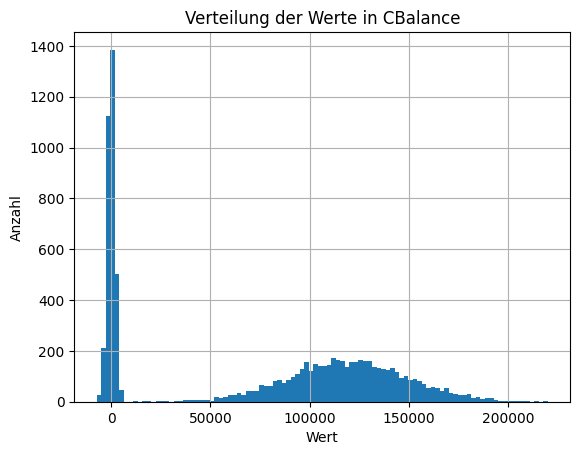


Anzahl der Kunden mit negativem Kontostand:  1637
Anzahl der Kunden mit Kontostand 0:  0
Anzahl der Kunden mit positivem Kontostand:  7025

CBalance_is_zero ist eine konstante Spalte (alle Werte identisch) und wird entfernt.


In [14]:
# Überprüfe zunächst auf NaN-Werte
print("Es gibt insgesamt", df['CBalance'].isna().sum(), "NaN Werte in CBalance.\n")

# Zeige die Verteilung an
plt.hist(df['CBalance'], bins=100)
plt.title("Verteilung der Werte in CBalance")
plt.xlabel("Wert")
plt.ylabel("Anzahl")
plt.grid()
plt.show()

# Median-Imputation für fehlende Werte
median_balance = df['CBalance'].median()
df['CBalance'] = df['CBalance'].fillna(median_balance)

# Dummy-Feature für negative Kontostände
df['CBalance_is_negative'] = np.where(df['CBalance'] < 0, 1, 0)

# Dummy-Feature für Kontostand ≈ 0 (wegen Float-Präzision besser ein Toleranzwert)
epsilon = 1e-6
df['CBalance_is_zero'] = np.where(np.abs(df['CBalance']) < epsilon, 1, 0)

# Statistiken ausgeben
print("\nAnzahl der Kunden mit negativem Kontostand: ", df['CBalance_is_negative'].sum())
print("Anzahl der Kunden mit Kontostand 0: ", df['CBalance_is_zero'].sum())
print("Anzahl der Kunden mit positivem Kontostand: ", df[(df['CBalance_is_negative'] == 0) & (df['CBalance_is_zero'] == 0)].shape[0])

# Da Median-Imputation keinen Wert exakt gleich 0 erzeugt, ist CBalance_is_zero nach der Imputation
# eine konstante Spalte ohne Informationsgehalt und wird entfernt.
if df['CBalance_is_zero'].nunique() == 1:
    print("\nCBalance_is_zero ist eine konstante Spalte (alle Werte identisch) und wird entfernt.")
    df.drop('CBalance_is_zero', axis=1, inplace=True)

In [15]:
# Überprüfe das Geschlecht auf korrekte Werte
print("Einzigartige Geschlechter vor der Korrektur: ", df['CGender'].unique(), "\n")

# Normalisiere Groß-/Kleinschreibung und führende/nachfolgende Leerzeichen
df['CGender'] = df['CGender'].str.strip().str.capitalize()

# Überprüfe die einzigartigen Geschlechter erneut
print("Einzigartige Geschlechter nach der Korrektur: ", df['CGender'].unique(), "\n")

# Konvertiere das Geschlecht in categorischen Datentyp
df['CGender'] = df['CGender'].astype('category')

print("CGender ist jetzt vom Datentyp", df['CGender'].dtype)

Einzigartige Geschlechter vor der Korrektur:  ['Male' 'Female'] 

Einzigartige Geschlechter nach der Korrektur:  ['Male' 'Female'] 

CGender ist jetzt vom Datentyp category


In [16]:
# Berechne Mittelwert und Standardabweichung des Alters
mean = df['CAge'].mean()
std = df['CAge'].std()

# Definiere die untere und obere Grenze für akzeptable Alterswerte und entferne extreme Outlier
lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

# Berechne minimales und maximales Alter im statistischen 2σ-Bereich
df_filtered = df[(df['CAge'] >= lower_bound) & (df['CAge'] <= upper_bound)]
min_age_stat = df_filtered['CAge'].min()
max_age_stat = df_filtered['CAge'].max()

# Zeige statistische Grenzen transparent an (kann bei fehlerhaften Daten < 18 enthalten)
print(f"Statistische Altersgrenzen (2σ): [{lower_bound:.2f}, {upper_bound:.2f}]")
print("Min. Alter im statistischen Bereich:", min_age_stat)
print("Max. Alter im statistischen Bereich:", max_age_stat, "\n")

# Fachliche Altersregel: keine Minderjährigen/negativen Alter
valid_min_age = 18

# Zeige Anzahl der Personen die über/unter den Grenzen liegen (vor Bearbeitung)
print(f"Personen über {max_age_stat} Jahre:", df[df['CAge'] > max_age_stat].shape[0])
print(f"Personen unter {valid_min_age} Jahre:", df[df['CAge'] < valid_min_age].shape[0], "\n")

# Setze Personen über max_age_stat auf max_age_stat (Capping oberer Rand)
df.loc[df['CAge'] > max_age_stat, 'CAge'] = max_age_stat

# Setze Personen unter 18 auf 18 (Geschäftsfähigkeit/Volljährigkeit)
df.loc[df['CAge'] < valid_min_age, 'CAge'] = valid_min_age

# Überprüfe nach der Bearbeitung
print("Nach der Bearbeitung:")
print(f"Personen über {max_age_stat} Jahre:", df[df['CAge'] > max_age_stat].shape[0])
print(f"Personen unter {valid_min_age} Jahre:", df[df['CAge'] < valid_min_age].shape[0])
print("Finale fachliche Altersgrenzen im Datensatz:", df['CAge'].min(), "bis", df['CAge'].max())

Statistische Altersgrenzen (2σ): [-8.01, 84.91]
Min. Alter im statistischen Bereich: -1
Max. Alter im statistischen Bereich: 84 

Personen über 84 Jahre: 13
Personen unter 18 Jahre: 2 

Nach der Bearbeitung:
Personen über 84 Jahre: 0
Personen unter 18 Jahre: 0
Finale fachliche Altersgrenzen im Datensatz: 18 bis 84


In [17]:
# Prüfe Art der Finanzprodukte (Sollte nur 1-4 geben)
print("Vor der Bearbeitung gibt es folgende financial products: ", df['CNumOfProducts'].unique(), "\n")

# Zeige fehlerhafte Einträge
print("Davon gibt es", df[df['CNumOfProducts'] == 99].count()[['CNumOfProducts']].values[0], "Zeilen mit dem Wert 99.\n")

# Zeige fehlerhafte Einträge
print(df[(df['CNumOfProducts'].isin([18, 99]))])

# Entferne fehlerhafte Einträge mit der Zahl 99 und 18 und prüfe Anzahl Zeilen
df = df[~df['CNumOfProducts'].isin([99, 18])]

# Prüfe Art der Finanzprodukte (Sollte nur 1-4 geben)
print("\n Nach der Bearbeitung gibt es folgende financial products: ", df['CNumOfProducts'].unique(), "\n")

Vor der Bearbeitung gibt es folgende financial products:  [1 2 3 4] 

Davon gibt es 0 Zeilen mit dem Wert 99.

Empty DataFrame
Columns: [Customer_ID, CCreditScore, CGeography, CGender, CAge, CTenure, CBalance, CNumOfProducts, CHasCrCard, CIsActiveMember, CEstimatedSalary, Days_Since_Onboarding, Account_Age_Months, Avg_Monthly_Transactions, Transaction_Variance, Last_Login_Days_Ago, Support_Tickets_Count, Mobile_App_Usage_Hours, Onboarding_Month, Is_Holiday_Onboarding, Churn, CLV_Continuous, CBalance_is_negative]
Index: []

[0 rows x 23 columns]

 Nach der Bearbeitung gibt es folgende financial products:  [1 2 3 4] 



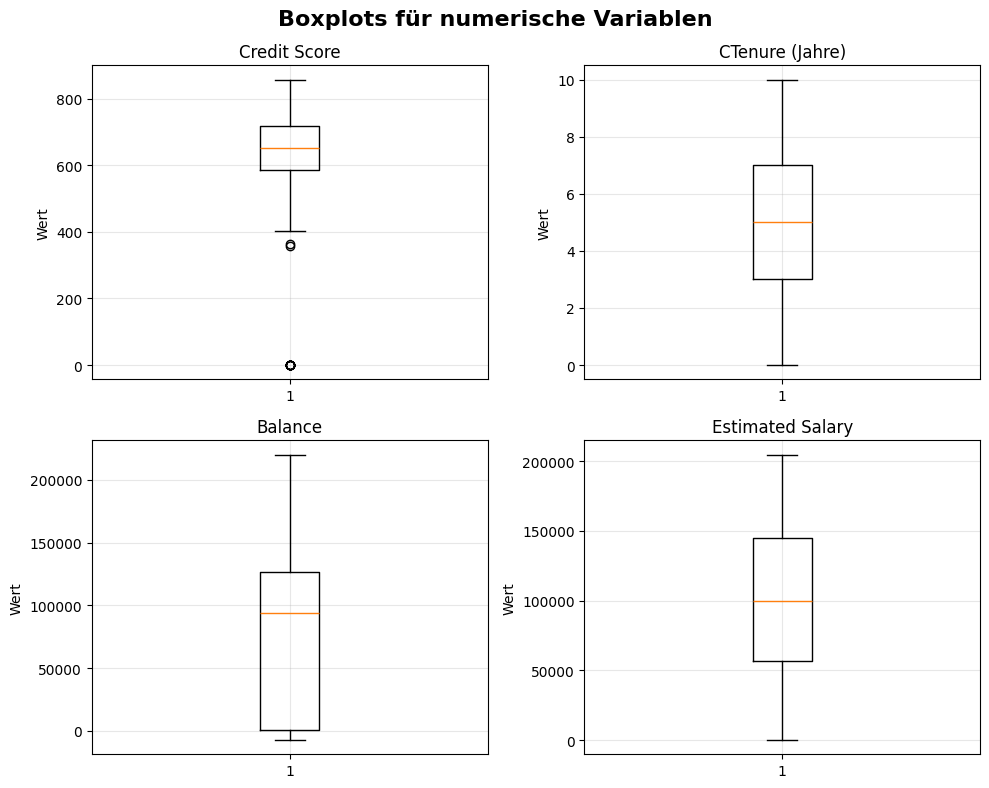

In [18]:
# Boxplots zur Identifikation von Outliers in den demografischen Daten (hint: hätte man auch mit allen Werten auf einmal machen können)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Boxplots für numerische Variablen', fontsize=16, fontweight='bold')

# CCreditScore
axes[0, 0].boxplot(df['CCreditScore'])
axes[0, 0].set_title('Credit Score')
axes[0, 0].set_ylabel('Wert')
axes[0, 0].grid(True, alpha=0.3)

# CTenure
axes[0, 1].boxplot(df['CTenure'])
axes[0, 1].set_title('CTenure (Jahre)')
axes[0, 1].set_ylabel('Wert')
axes[0, 1].grid(True, alpha=0.3)

# CBalance
axes[1, 0].boxplot(df['CBalance'])
axes[1, 0].set_title('Balance')
axes[1, 0].set_ylabel('Wert')
axes[1, 0].grid(True, alpha=0.3)

# CEstimatedSalary
axes[1, 1].boxplot(df['CEstimatedSalary'])
axes[1, 1].set_title('Estimated Salary')
axes[1, 1].set_ylabel('Wert')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Zur Behandlung von Ausreißern (Outlier) gibt es verschiedene Methoden. Eine recht einfache Methode, die IQR - Methode soll hier zur Anwendung kommen. In der Praxis werden dabei meist Werte der Inter-Quartil-Range von 1.5 bis 3 angenommen. Aus dem obgigen Boxplot und der Berechnung (siehe unten) wird ersichtlich, dass ein iqr von 1,5 für die Spalte CCreditScore und CTenure ausreichend ist.

In [19]:
# Definiere eine Funktion zur Berechnung der Inter Quantile Range (IQR)
def inter_quartile_range(column: pd.Series, iqr: float=1.5) -> tuple:
    """
    Berechnet die Interquartilbereichsgrenzen für eine gegebene Spalte.
    Args:
        column (pd.Series): Die Spalte, für die die IQR-Grenzen berechnet werden sollen.
    Returns:
        tuple: Ein Tupel mit dem unteren und oberen Grenzwert des IQR.
    """
    Q3 = np.quantile(column, 0.75)
    Q1 = np.quantile(column, 0.25)
    IQR = Q3 - Q1
    lower_bound = Q1 - iqr * IQR
    upper_bound = Q3 + iqr * IQR
    return lower_bound, upper_bound

In [20]:
# Berechne Inter Quantile Range (IQR) für CCreditScore
lower_bound, upper_bound = inter_quartile_range(df['CCreditScore'])

# Berechne Anzahl Zeilen vor Bearbeitung
rows_before = df.shape[0]

# Ausgabe der Werte und Grenzen (siehe auch Boxplot oben)
print("Der untere Wert des Kredit Scores liegt bei: ", df['CCreditScore'].min())
print("Die untere Grenze des Kredit Scores liegt bei: ", lower_bound)
print("Der obere Wert des Kredit Scores liegt bei: ", df['CCreditScore'].max())
print("Die obere Grenze des Kredit Scores liegt bei: ", upper_bound)

# Entferne Ausreißer mit der Inter-Quantile-Range (IQR)-Methode
df = df[(df['CCreditScore'] >= lower_bound) & (df['CCreditScore'] <= upper_bound)]

# Berechne Anzahl Zeilen nach Bearbeitung
rows_after = df.shape[0]

# Ausgabe
print("Es wurden insgesamt", rows_before - rows_after, "Zeilen entfernt.")

Der untere Wert des Kredit Scores liegt bei:  0.0
Die untere Grenze des Kredit Scores liegt bei:  384.8683310246385
Der obere Wert des Kredit Scores liegt bei:  857.4577549530931
Die obere Grenze des Kredit Scores liegt bei:  917.031271273406
Es wurden insgesamt 15 Zeilen entfernt.


In [21]:
# Berechne Inter Quantile Range (IQR) für CTenure
lower_bound, upper_bound = inter_quartile_range(df['CTenure'])

# Berechne Anzahl Zeilen vor Bearbeitung
rows_before = df.shape[0]

# Ausgabe der Werte und Grenzen (siehe auch Boxplot oben)
print("Der untere Wert für die Anzahl der Zugehörigkeit in Jahren liegt bei: ", df['CTenure'].min())
print("Die untere Grenze für die Anzahl der Zugehörigkeit in Jahren liegt bei: ", lower_bound)
print("Der obere Wert für die Anzahl der Zugehörigkeit in Jahren liegt bei: ", df['CTenure'].max())
print("Die obere Grenze für die Anzahl der Zugehörigkeit in Jahren liegt bei: ", upper_bound)

# Entferne Ausreißer mit der Inter-Quantile-Range (IQR)-Methode
df = df[(df['CTenure'] >= lower_bound) & (df['CTenure'] <= upper_bound)]

# Berechne Anzahl Zeilen nach Bearbeitung
rows_after = df.shape[0]

# Ausgabe
print("Es wurden insgesamt", rows_before - rows_after, "Zeilen entfernt.")

Der untere Wert für die Anzahl der Zugehörigkeit in Jahren liegt bei:  0
Die untere Grenze für die Anzahl der Zugehörigkeit in Jahren liegt bei:  -3.0
Der obere Wert für die Anzahl der Zugehörigkeit in Jahren liegt bei:  10
Die obere Grenze für die Anzahl der Zugehörigkeit in Jahren liegt bei:  13.0
Es wurden insgesamt 0 Zeilen entfernt.


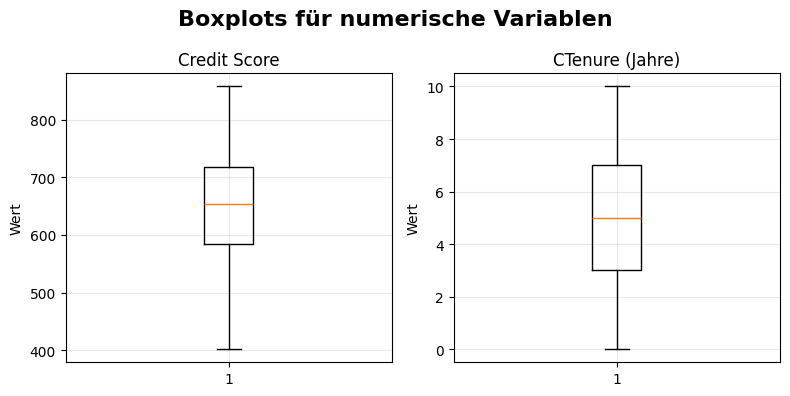

In [22]:
# Boxplots zur Überprüfung nach der Entfernung der Outliers
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
fig.suptitle('Boxplots für numerische Variablen', fontsize=16, fontweight='bold')

# CCreditScore
axes[0].boxplot(df['CCreditScore'])
axes[0].set_title('Credit Score')
axes[0].set_ylabel('Wert')
axes[0].grid(True, alpha=0.3)

# CTenure
axes[1].boxplot(df['CTenure'])
axes[1].set_title('CTenure (Jahre)')
axes[1].set_ylabel('Wert')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# Überprüfe die Werte für eine Kreditkarte (erlaubt: 0 oder 1)
print("Werte für CHasCrCard:", df['CHasCrCard'].unique())

# Überprüfe die Werte für eine aktive Mitgliedschaft (erlaubt: 0 oder 1)
print("Werte für CIsActiveMember:", df['CIsActiveMember'].unique())

# Überprüfe Is_Holiday_Onboarding (erwartet: 0 oder 1, keine Null-Werte)
print("\nWerte für Is_Holiday_Onboarding:", df['Is_Holiday_Onboarding'].unique())
print("Null-Werte in Is_Holiday_Onboarding:", df['Is_Holiday_Onboarding'].isnull().sum())
print("Verteilung Is_Holiday_Onboarding:")
print(df['Is_Holiday_Onboarding'].value_counts())

Werte für CHasCrCard: [1 0]
Werte für CIsActiveMember: [0 1]

Werte für Is_Holiday_Onboarding: [0 1]
Null-Werte in Is_Holiday_Onboarding: 0
Verteilung Is_Holiday_Onboarding:
Is_Holiday_Onboarding
0    7148
1    1499
Name: count, dtype: int64


### Überprüfe und Säubere Temporal & Behavioral Features

In [24]:
# Aufgrund von Redundanz und dem Vorschlag für die Spalte Account_Age_Months, werde ich diese entfernen
df.drop(['Days_Since_Onboarding'], axis=1, inplace=True)
print(df.columns)

Index(['Customer_ID', 'CCreditScore', 'CGeography', 'CGender', 'CAge',
       'CTenure', 'CBalance', 'CNumOfProducts', 'CHasCrCard',
       'CIsActiveMember', 'CEstimatedSalary', 'Account_Age_Months',
       'Avg_Monthly_Transactions', 'Transaction_Variance',
       'Last_Login_Days_Ago', 'Support_Tickets_Count',
       'Mobile_App_Usage_Hours', 'Onboarding_Month', 'Is_Holiday_Onboarding',
       'Churn', 'CLV_Continuous', 'CBalance_is_negative'],
      dtype='object')


In [25]:
# Überprüfe die Werte in der Spalte Onboarding_Month
print("Es gibt folgende Werte: ", df['Onboarding_Month'].unique(), "\n")

# Pattern-Matching
num_months = {1: "January", 2: "February", 3: "March", 4: "April", 5: "May", 6: "June", 7: "July",
            8: "August", 9: "September", 10: "October", 11: "November", 12: "December"}

seasons = {
    'Winter': ['December', 'January', 'February'],
    'Spring': ['March', 'April', 'May'],
    'Summer': ['June', 'July', 'August'],
    'Autumn': ['September', 'October', 'November']
}

# Mapping-Funktion für die Jahreszeiten
def get_season(month: int) -> str:
    month_name = num_months[month]
    for season, months in seasons.items():
        if month_name in months:
            return season
    return "Unknown"

# Neue Spalte CSeason mit Jahreszeiten befüllen und zum Datensatz hinzufügen
df['CSeason'] = df['Onboarding_Month'].apply(get_season).astype('category')

# Ausgabe (Summary)
print("Unique seasons assigned: ", df['CSeason'].unique(), "\n")
print("Verteilung der Jahreszeiten:")
print(df['CSeason'].value_counts())
print(f"\nEs wurden insgesamt {df.shape[0]} Zeilen mit Jahreszeiten befüllt.\n")

# Wandle die Jahreszeiten in categorical
df['CSeason'] = df['CSeason'].astype('category')
print("Der Datentyp von CSeason ist nun", df['CSeason'].dtype)

Es gibt folgende Werte:  [ 8 11  2  1  3  5  7 10  9  4  6 12] 

Unique seasons assigned:  ['Summer', 'Autumn', 'Winter', 'Spring']
Categories (4, object): ['Autumn', 'Spring', 'Summer', 'Winter'] 

Verteilung der Jahreszeiten:
CSeason
Winter    2194
Summer    2187
Spring    2151
Autumn    2115
Name: count, dtype: int64

Es wurden insgesamt 8647 Zeilen mit Jahreszeiten befüllt.

Der Datentyp von CSeason ist nun category


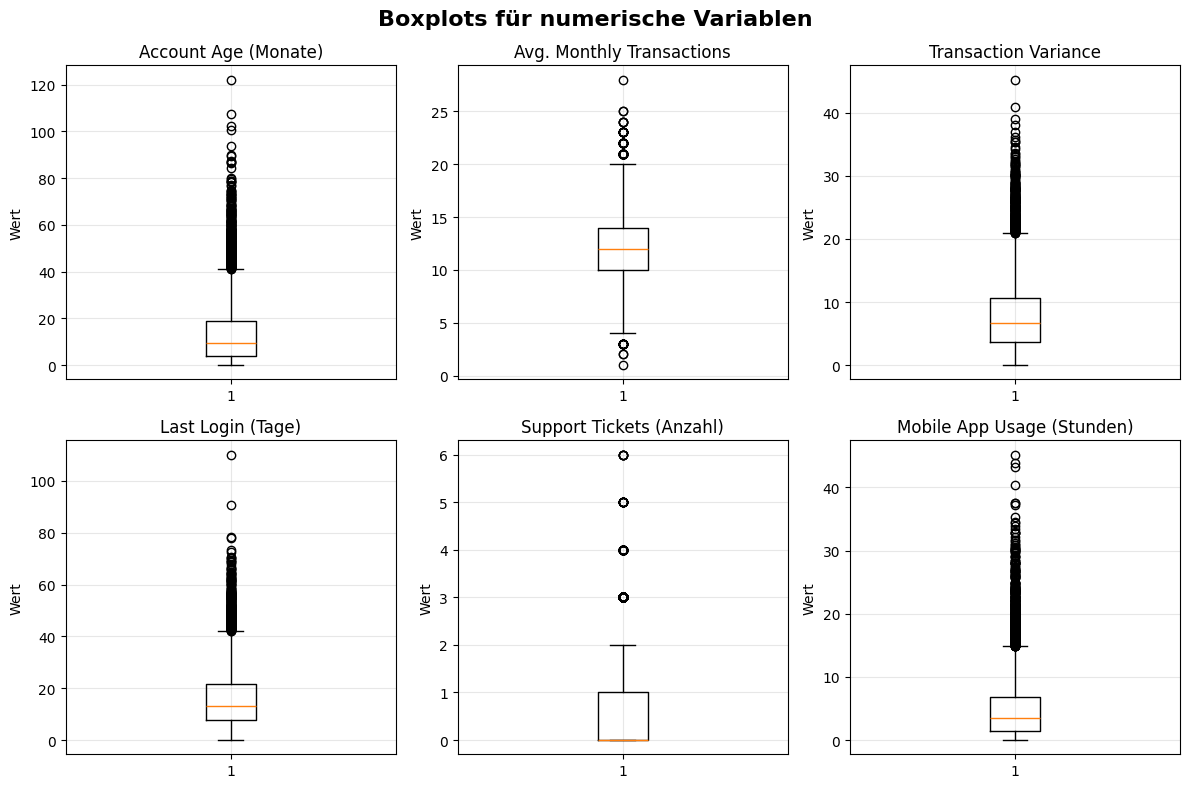

In [26]:
# Boxplots zur Identifikation von Ausreißern bei den Temporal & Behavioral Features
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Boxplots für numerische Variablen', fontsize=16, fontweight='bold')

# CAccount_Age_Months
axes[0, 0].boxplot(df['Account_Age_Months'])
axes[0, 0].set_title('Account Age (Monate)')
axes[0, 0].set_ylabel('Wert')
axes[0, 0].grid(True, alpha=0.3)

# CAvg_Monthly_Transactions
axes[0, 1].boxplot(df['Avg_Monthly_Transactions'])
axes[0, 1].set_title('Avg. Monthly Transactions')
axes[0, 1].set_ylabel('Wert')
axes[0, 1].grid(True, alpha=0.3)

# CTransaction_Variance
axes[0, 2].boxplot(df['Transaction_Variance'])
axes[0, 2].set_title('Transaction Variance')
axes[0, 2].set_ylabel('Wert')
axes[0, 2].grid(True, alpha=0.3)

# Last Login
axes[1, 0].boxplot(df['Last_Login_Days_Ago'])
axes[1, 0].set_title('Last Login (Tage)')
axes[1, 0].set_ylabel('Wert')
axes[1, 0].grid(True, alpha=0.3)

# Support Tickets
axes[1, 1].boxplot(df['Support_Tickets_Count'])
axes[1, 1].set_title('Support Tickets (Anzahl)')
axes[1, 1].set_ylabel('Wert')
axes[1, 1].grid(True, alpha=0.3)

# Mobile Usage
axes[1, 2].boxplot(df['Mobile_App_Usage_Hours'])
axes[1, 2].set_title('Mobile App Usage (Stunden)')
axes[1, 2].set_ylabel('Wert')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Insgesamt beginnen Werte minimum bei 0. Die Spalte "Account_Age_Months" wird nicht mit IQR behandelt, da es sich bei Ausreißern um Langzeitkunden handeln könnte. Demnach würden wichtige Informationen entfernt. Genauso würden Kunden, die lange nicht eingeloggt waren, aber nicht gekündigt haben, ein besonderes Nutzungsmuster darstellen. Ggf. sind dies "passive" Kunden, die das Konto behalten, aber kaum nutzen. Für die Anzahl der Tickets würde ich eine IQR von 3 vorschlagen (nicht so extrem). Mehr Tickets könnten darauf hindeuten, dass es zu Fehlern beim erstellen gekommen ist, wie zum Beispiel durch Duplikate oder es wurden Tickets abgesendet, aber nicht richtig ausgefüllt (Neuerstellung notwendig für die gleiche Transaktion). Bei den App-Nutzern würde ich die Werte belassen. Es gibt eben Personen die sehr oft auf ihr Konto schauen und Personen die dies weniger tun. Insgesamt gibt es keine rießigen Ausreißer. Deshalb erscheinen die Daten valide. Die monatlichen Transaktionen könnten mit der IQR - Methode bereinigt werden. Dadurch würde die Varianz der Transaktionen weniger streuen.  

In [27]:
# Zähle die Anzahl der Zeilen vor der Bearbeitung
rows_before = df.shape[0]

# Berechne Inter Quantile Range (IQR) für Support_Tickets_Count
lower_bound, upper_bound = inter_quartile_range(column=df['Support_Tickets_Count'], iqr=3)
print("Support_Tickets_Count - Untere Grenze:", lower_bound)
print("Support_Tickets_Count - Obere Grenze:", upper_bound)

# Entferne Ausreißer mit der Inter-Quantile-Range (IQR)-Methode
df = df[(df['Support_Tickets_Count'] >= lower_bound) & (df['Support_Tickets_Count'] <= upper_bound)]

# Zähle die Anzahl der Zeilen nach der Bearbeitung
rows_after = df.shape[0]

# Ausgabe
print("Es wurden insgesamt", rows_before - rows_after, "Zeilen entfernt.")

# change into int value
df['Support_Tickets_Count'] = df['Support_Tickets_Count'].astype('int')

Support_Tickets_Count - Untere Grenze: -3.0
Support_Tickets_Count - Obere Grenze: 4.0
Es wurden insgesamt 18 Zeilen entfernt.


In [28]:
# Zähle die Anzahl der Zeilen vor der Bearbeitung
rows_before = df.shape[0]

# Berechne Inter Quantile Range (IQR) für Avg_Monthly_Transactions
lower_bound, upper_bound = inter_quartile_range(column=df['Avg_Monthly_Transactions'], iqr=1.5)
print("Avg_Monthly_Transactions - Untere Grenze:", lower_bound)
print("Avg_Monthly_Transactions - Obere Grenze:", upper_bound)

# Entferne Ausreißer mit der Inter-Quantile-Range (IQR)-Methode
df = df[(df['Avg_Monthly_Transactions'] >= lower_bound) & (df['Avg_Monthly_Transactions'] <= upper_bound)]

# Zähle die Anzahl der Zeilen nach der Bearbeitung
rows_after = df.shape[0]

# Ausgabe
print("Es wurden insgesamt", rows_before - rows_after, "Zeilen entfernt.")

Avg_Monthly_Transactions - Untere Grenze: 4.0
Avg_Monthly_Transactions - Obere Grenze: 20.0
Es wurden insgesamt 108 Zeilen entfernt.


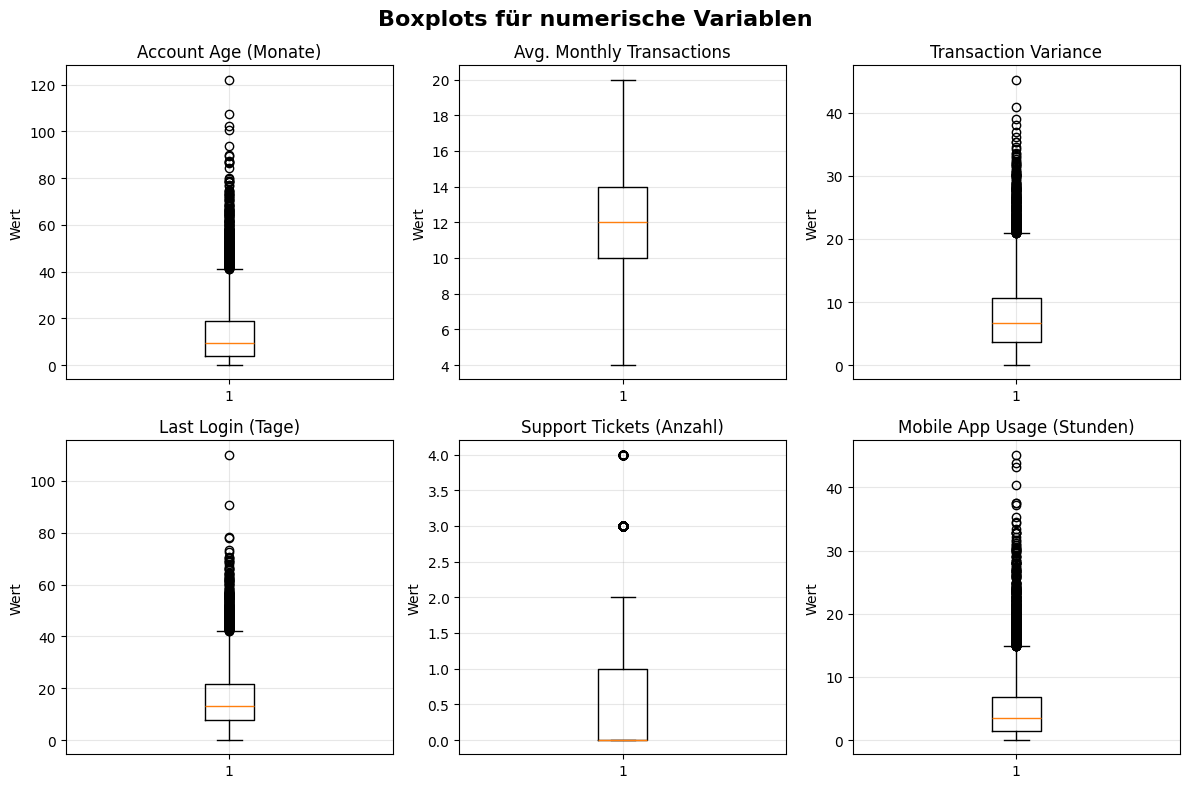

In [29]:
# Boxplots zur Identifikation von Ausreißern bei den Temporal & Behavioral Features
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Boxplots für numerische Variablen', fontsize=16, fontweight='bold')

# CAccount_Age_Months
axes[0, 0].boxplot(df['Account_Age_Months'])
axes[0, 0].set_title('Account Age (Monate)')
axes[0, 0].set_ylabel('Wert')
axes[0, 0].grid(True, alpha=0.3)

# CAvg_Monthly_Transactions
axes[0, 1].boxplot(df['Avg_Monthly_Transactions'])
axes[0, 1].set_title('Avg. Monthly Transactions')
axes[0, 1].set_ylabel('Wert')
axes[0, 1].grid(True, alpha=0.3)

# CTransaction_Variance
axes[0, 2].boxplot(df['Transaction_Variance'])
axes[0, 2].set_title('Transaction Variance')
axes[0, 2].set_ylabel('Wert')
axes[0, 2].grid(True, alpha=0.3)

# Last Login
axes[1, 0].boxplot(df['Last_Login_Days_Ago'])
axes[1, 0].set_title('Last Login (Tage)')
axes[1, 0].set_ylabel('Wert')
axes[1, 0].grid(True, alpha=0.3)

# Support Tickets
axes[1, 1].boxplot(df['Support_Tickets_Count'])
axes[1, 1].set_title('Support Tickets (Anzahl)')
axes[1, 1].set_ylabel('Wert')
axes[1, 1].grid(True, alpha=0.3)

# Mobile Usage
axes[1, 2].boxplot(df['Mobile_App_Usage_Hours'])
axes[1, 2].set_title('Mobile App Usage (Stunden)')
axes[1, 2].set_ylabel('Wert')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Mit IQR von 1.5 wurden insgesamt zwar 108 Zeilen entfernt, aber die monatliche Transaktionsrate besteht nun ohne Ausreißer. Insgesamt können Transaktionen zwar einen niedrigen Durchschnitt (z.B. 5 Transaktionen/Monat), aber eine hohe Varianz haben (mal 0, mal 15 Transaktionen). Dabei handelt es sich um ein legitimes Verhaltensmuster und keinen Fehler. Beispielsweise würde ein Student selten Transaktionen ausführen (niedriger Avg). Sobald er Geld bekommt, würde er viele Transaktionen durchführen (hohe Varianz). Weitere Beispiele erklären sich von selbst. Demnach ist die Variance mehr oder weniger vairabel/flexibel und besitzt eine höhere Anzahl von "Ausreißern". Aus diesem Grund würde ich die Varianz auch nicht weiter behandeln.

Bei einigen Temporal & Behavioral Features wurde bewusst auf eine Ausreißer-Entfernung verzichtet, da hohe Werte in Account_Age_Months Langzeitkunden darstellen (wichtig für Retention-Analyse). Extreme Werte in Last_Login_Days_Ago repräsentieren das wichtigste Churn-Signal. Hohe Mobile_App_Usage_Hours deuten auf engagierte, loyale Kunden hin. Lediglich Support_Tickets_Count wurde mit IQR 3.0 behandelt, um offensichtliche Systemfehler (z.B. Duplikate) zu entfernen.

In [30]:
# Kompakter Skewness-Check
skew_cols = [
    'CAge', 'Account_Age_Months', 'Transaction_Variance',
    'Last_Login_Days_Ago', 'Support_Tickets_Count', 'Mobile_App_Usage_Hours'
]

skew_table = df[skew_cols].skew().sort_values(ascending=False).round(3)
print("Skewness (ausgewählte Features):")
print(skew_table)

high_skew = skew_table[skew_table.abs() >= 1]
print("\nStark schief (|skew| >= 1):", list(high_skew.index))
print("Entscheidung: Transformation nur modellabhängig prüfen (v. a. lineare/distanzbasierte Modelle), nicht global.")

Skewness (ausgewählte Features):
Mobile_App_Usage_Hours    2.098
Account_Age_Months        1.842
Support_Tickets_Count     1.610
Last_Login_Days_Ago       1.418
Transaction_Variance      1.364
CAge                      1.257
dtype: float64

Stark schief (|skew| >= 1): ['Mobile_App_Usage_Hours', 'Account_Age_Months', 'Support_Tickets_Count', 'Last_Login_Days_Ago', 'Transaction_Variance', 'CAge']
Entscheidung: Transformation nur modellabhängig prüfen (v. a. lineare/distanzbasierte Modelle), nicht global.


### Skewness-Check (kurz) und Transformationsentscheidung

Für stark schiefe Features (|skew| >= 1) wird die Transformation **modellabhängig** entschieden:
- **Lineare/distanzbasierte Modelle:** Transformation (z. B. `log1p`) und anschließende Skalierung prüfen.
- **Baumbasierte Modelle:** keine zwingende Transformation notwendig.

### Überprüfe und Säubere Target Variables

Es gibt für die Spalte Churn insgesamt folgende Werte: [0 1] 

Es wurden insgesamt folgende Churn-Kategorien gefunden: ['No Churn', 'Churn']
Categories (2, object): ['Churn', 'No Churn'] 

Es wurden insgesamt: 8521 Zeilen hinzugefügt. Von insgesamt: 8521 



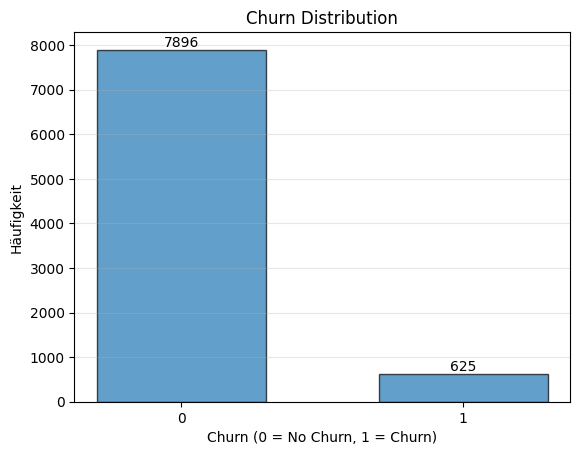

In [31]:
# Überprüfe die Spalte Churn
print("Es gibt für die Spalte Churn insgesamt folgende Werte:", df['Churn'].unique(), "\n")

# Füge eine neue (extra) Spalte Churn_Category zum Datensatz hinzu
df['Churn_Category'] = df['Churn'].apply(lambda x: 'No Churn' if x == 0 else 'Churn' if x == 1 else 'Unknown').astype('category')

# Prüfe die neue Spalte Churn_Category
print("Es wurden insgesamt folgende Churn-Kategorien gefunden:", df['Churn_Category'].unique(), "\n")
print("Es wurden insgesamt:", len(df['Churn_Category']), "Zeilen hinzugefügt. Von insgesamt:", df.shape[0], "\n")

# BarChart der Spalte Churn mit den Klassen 0 und 1
churn_counts = df['Churn'].value_counts().sort_index()
bars = plt.bar(churn_counts.index, churn_counts.values, edgecolor='black', alpha=0.7, width=0.6)
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = No Churn, 1 = Churn)')
plt.ylabel('Häufigkeit')
plt.xticks([0, 1])
plt.grid(axis='y', alpha=0.3)
bars = plt.bar_label(bars, fmt='%d')
plt.show()

Das sog. "target label" für Churn ist unbalanciert. Nur rund 7,9% der Datensätze sind Churn = 1. D. h. wenig Kunden wandern ab (positiv). Im Gegensatz dazu sind No Churn labels mit 92,1% im Datensatz vertreten. Das bedeutet die Machine Learning Modelle werden Churns (Minderheitsklasse) nicht gut bzw. richtig prädizieren. Folglich würde die Accuracy zwar hoch ausfallen, aber nur, weil die Mehrheitsklasse richtig prädiziert würde. Anders ausgedrückt würde überwiegend die Mehrheitsklasse richtig präziziert werden. Ellgemein sollte eine Accuracy von z.B. über 90% jeden Anwender eher stutzig machen. 

Eine Methode damit umzugehen ist SMOTE (Synthetic minority oversampling technique). Hierbei werden synthetische Daten erzeugt, ohne ein overfitting, also eine Überanpassung, des Modells zu erzeugen. Im Gegensatz dazu führt ein Resampling (Random-Oversamplig) eher zur Überanpassung des Modells. Eine weitere Methode wäre das sog. Undersampling, bei dem Daten aus der Mehrheitsklasse entfernt würden, bis eine gleichmäßige Durchmischung erreicht ist. Dadurch würde die Gesamtzahl der Samples minimiert und der Datensatz insgesamt kleiner werden. Schließlich würde ich mich für SMOTE entscheiden, wenn ich zu task 2 gelange und feststelle, dass die Performance der Modelle nicht gut ist.

Hinweis: Random Forests und die Logistische Regression werden als Modelle deklariert, die gut mit kleinen und unbalancierten Datensätzen umgehen können.

[source1](https://www.youtube.com/watch?v=GR-OW5asKlk)

[source2](https://www.youtube.com/watch?v=flhjn6e6wnY)

=== Statistik === 
count     8521.000000
mean     13674.753402
std       5448.529740
min       1428.027822
25%       9066.356904
50%      14030.258672
75%      18008.789676
max      29123.502825
Name: CLV_Continuous, dtype: float64 

Anzahl Null Werte: 0
Anzahl negative Werte: 0
Anzahl positive Werte: 8521
Schiefe -0.001
Kurtosis -0.976


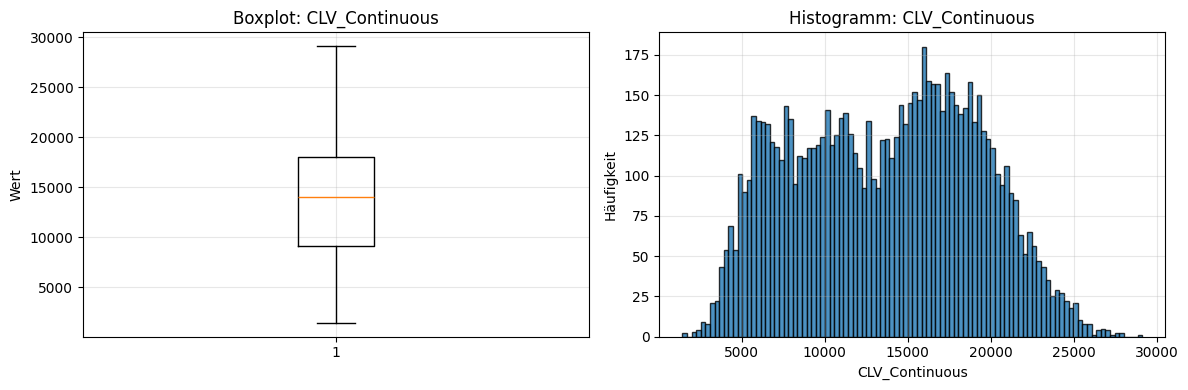

In [32]:
# Überprüfe die Spalte CLV_Continuous
print("=== Statistik === ")
print(df['CLV_Continuous'].describe(), "\n") 
print("Anzahl Null Werte:", df['CLV_Continuous'].isna().sum())
print("Anzahl negative Werte:", df['CLV_Continuous'].apply(lambda x: x < 0).sum())
print("Anzahl positive Werte:", df['CLV_Continuous'].apply(lambda x: x > 0).sum())
print("Schiefe", round(skew(df['CLV_Continuous']), 3))
print("Kurtosis", round(kurtosis(df['CLV_Continuous']), 3))

# Boxplot und Histogramm nebeneinander
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df['CLV_Continuous'])
axes[0].set_title('Boxplot: CLV_Continuous')
axes[0].set_ylabel('Wert')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['CLV_Continuous'], bins=100, edgecolor='black', alpha=0.8)
axes[1].set_title('Histogramm: CLV_Continuous')
axes[1].set_xlabel('CLV_Continuous')
axes[1].set_ylabel('Häufigkeit')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Die Zielvariable CLV_Continuous besitzt weder Ausreißer, noch eine Schiefe in der Verteilung der Daten. Mit einem Wert von nahezu 0, sind die Daten perfekt symmetrisch verteilt. Es gibt keine Hinweise auf problematische Heavy-Tail-/Ausreißer an den Rändern der Verteilung (siehe Kurtosis = -0.976). Außerdem gibt es keine Nullwerte und auch keine negativen Werte. Daher bedarf es keiner weiteren Bearbeitung bzw. Säuberung von CLV_Continuous. 

In [33]:
# Zeige die Anzahl der Zeilen, die durch das Data-Cleaning beseitigt werden mussten
rows_at_end = df.shape[0]

print("Es wurden insgesamt:", rows_at_begin - rows_at_end, "Zeilen durch das Data-Cleaning entfernt.")
print("Der Datensatz enthält nun insgesamt:", df.shape[0], "Zeilen und", df.shape[1], "Spalten.")

Es wurden insgesamt: 141 Zeilen durch das Data-Cleaning entfernt.
Der Datensatz enthält nun insgesamt: 8521 Zeilen und 24 Spalten.


### Feature Engineering

#### Dummie-Encoding für kategorische Variablen

In [34]:
# Setze Dummie-Encoding ein: Werte (0 | 1) für kategorische Variablen ein, wie CGeography, CGender und season
# drop_first=True verhindert Multikollinearität, da die erste Spalte weggelassen wird (Besonders wichtig für Logistische Regression!)
df = pd.get_dummies(df, columns=['CGeography', 'CGender', 'CSeason'], drop_first=True, dtype=int)

# WICHTIG: Entferne redundante und problematische Spalten für ML-Datensatz
# - Onboarding_Month: Redundant (CSeason vorhanden)
# - Churn_Category: Redundant (Kopie von Churn)
# - Customer_ID: Identifier, nicht für ML relevant
df.drop(['Onboarding_Month', 'Churn_Category', 'Customer_ID'], axis=1, inplace=True)

#### Runde auf volle Zahlen (ohne Komma) für: Gehälter, avg. Monate des Accounts, Last_Login_Days_Ago

In [35]:
# Es genügt die Spalte der Gehälter und auch Monate auf volle Integer zu runden
df['CEstimatedSalary'] = round(df['CEstimatedSalary']).astype('int')
df['Account_Age_Months'] = round(df['Account_Age_Months']).astype('int')
df['Last_Login_Days_Ago'] = round(df['Last_Login_Days_Ago']).astype('int')

#### Runde auf weniger Nachkommastellen für den Credit-Score und Mobile_App_Usage_Hours

In [36]:
df['CCreditScore'] = round(df['CCreditScore'], 3).astype('float')
df['Mobile_App_Usage_Hours'] = round(df['Mobile_App_Usage_Hours'], 2).astype('float')
# df.head()

#### Schreibe die gesäuberten Daten in eine neue CSV-Datei

In [37]:
# Schreibe den ML-Modell gesäuberten Datensatz als csv zurück
df.to_csv("../data/dataset_cleaned.csv", index=False)

An dieser Stelle ist das sog. Data-Cleaning abgeschlossen! Schließlich werden die Daten für die Klassifikationsaufgaben vorbereitet. Ein 70/30-Split wurde gewählt, da der stark unbalancierte Datensatz (~7 % Churn) ein ausreichend großes Testset erfordert, um stabile Schätzungen für Recall und F1-Score zu gewährleisten.

In [38]:
# Lade die Daten
df = pd.read_csv("../data/dataset_cleaned.csv")  # Neuladen für sauberen Variablen-Zustand

# Teile den Datensatz auf in: Feature-Set und Zielvariable (Target Label)
X = df.drop(['Churn', 'CLV_Continuous'], axis=1)  # Alle Spalten außer Churn und CLV_Continuous
y = df['Churn']                                    # Target (0, 1)

# Überprüfe Datentypen
print("="*25, "Datentypen der Features:", "="*25, "\n")
print(X.dtypes, "\n")
print("="*25, "Datentyp der Zielvariable:", "="*25, "\n")
print(y.dtype, "\n")

# Train/Test-Split (30 % Testdaten)
# stratify=y stellt sicher, dass die Klassenverteilung (Churn ~7 %) in beiden Splits erhalten bleibt.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_RATIO,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Trainingsset: {X_train.shape[0]} Beobachtungen | Churn-Anteil: {y_train.mean():.2%}")
print(f"Testset:      {X_test.shape[0]}  Beobachtungen | Churn-Anteil: {y_test.mean():.2%}")

========================= Datentypen der Features: ========================= 

CCreditScore                float64
CAge                          int64
CTenure                       int64
CBalance                    float64
CNumOfProducts                int64
CHasCrCard                    int64
CIsActiveMember               int64
CEstimatedSalary              int64
Account_Age_Months            int64
Avg_Monthly_Transactions      int64
Transaction_Variance        float64
Last_Login_Days_Ago           int64
Support_Tickets_Count         int64
Mobile_App_Usage_Hours      float64
Is_Holiday_Onboarding         int64
CBalance_is_negative          int64
CGeography_Germany            int64
CGeography_Spain              int64
CGender_Male                  int64
CSeason_Spring                int64
CSeason_Summer                int64
CSeason_Winter                int64
dtype: object 

========================= Datentyp der Zielvariable: ========================= 

int64 

Trainingsset: 5964 Beoba

Im Folgenden ist eine Skalierung für den kNN und die logistische Regression notwendig, da diese Algorithmen auf Distanz- bzw. Gradientenberechnungen basieren und empfindlich auf unterschiedliche Wertebereiche reagieren. Beispielsweise liegen `CCreditScore`-Werte zwischen 400 und 850, `CBalance`-Werte hingegen im sechsstelligen Bereich – ohne Skalierung würde `CBalance` die Distanzberechnung stark dominieren.

Mit dem `StandardScaler` werden die Feature-Werte transformiert (z = (x − μ) / σ), sodass alle skalierten Features einen Mittelwert von 0 und eine Standardabweichung von 1 erhalten.

**Wichtig:** Binäre Spalten (0/1) und One-Hot-codierte Variablen werden bewusst **nicht** skaliert, da ihre Werte bereits eine eindeutige kategoriale Bedeutung besitzen und eine Skalierung diese verzerren würde.

In [39]:
# Bestimme, welche Spalten skaliert werden sollen
# Binäre Spalten (nur Werte 0 und 1) werden NICHT skaliert
binary_cols = [col for col in X_train.columns if set(X_train[col].unique()) <= {0, 1}]
scale_cols  = [col for col in X_train.columns if col not in binary_cols]

print(f"Zu skalierende Features:     {len(scale_cols)}")
print(f"Nicht skalierte (binäre):    {len(binary_cols)}")
print(f"Binäre Spalten: {binary_cols}")

# StandardScaler: fit NUR auf Trainingsdaten, damit Testdaten keinen Einfluss haben
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols]  = scaler.transform(X_test[scale_cols])

print("\nSkalierung abgeschlossen.")
pd.DataFrame(X_train_scaled[scale_cols]).head()

Zu skalierende Features:     12
Nicht skalierte (binäre):    10
Binäre Spalten: ['CHasCrCard', 'CIsActiveMember', 'Is_Holiday_Onboarding', 'CBalance_is_negative', 'CGeography_Germany', 'CGeography_Spain', 'CGender_Male', 'CSeason_Spring', 'CSeason_Summer', 'CSeason_Winter']

Skalierung abgeschlossen.


,CCreditScore,CAge,CTenure,CBalance,CNumOfProducts,CEstimatedSalary,Account_Age_Months,Avg_Monthly_Transactions,Transaction_Variance,Last_Login_Days_Ago,Support_Tickets_Count,Mobile_App_Usage_Hours
1819,0.854666,-0.297132,1.023164,0.857250,-1.009883,-0.017809,-0.702954,0.029336,-1.309771,2.409332,1.952777,-0.527362
655,-1.950143,0.380904,-0.710303,0.158637,-1.009883,1.136610,-0.174780,-0.579224,-1.154368,0.767862,-0.669097,-0.776468
1455,0.174264,0.671490,-0.710303,-1.151670,0.874642,1.168273,-0.929314,0.029336,-0.604587,-1.046394,1.952777,0.429521
281,-0.861488,-0.587718,-1.750384,1.194415,-1.009883,1.635387,-0.853861,0.637896,-0.808875,-0.787215,4.574652,-0.610397
1807,-1.020151,-1.556341,1.023164,-1.170998,0.874642,0.787797,-0.778408,-0.883504,-0.443810,-1.219181,-0.669097,-0.693433


In [40]:
df.describe()

,CCreditScore,CAge,CTenure,CBalance,CNumOfProducts,CHasCrCard,CIsActiveMember,CEstimatedSalary,Account_Age_Months,Avg_Monthly_Transactions,...,Is_Holiday_Onboarding,Churn,CLV_Continuous,CBalance_is_negative,CGeography_Germany,CGeography_Spain,CGender_Male,CSeason_Spring,CSeason_Summer,CSeason_Winter
count,8521.000000,8521.000000,8521.000000,8521.000000,8521.000000,8521.000000,8521.000000,8521.000000,8521.000000,8521.000000,...,8521.000000,8521.000000,8521.000000,8521.000000,8521.000000,8521.000000,8521.000000,8521.000000,8521.000000,8521.000000
mean,651.587720,37.990964,5.022063,74032.943075,1.535383,0.705903,0.542307,100747.367797,13.438329,11.899894,...,0.173454,0.073348,13674.753402,0.188593,0.225208,0.255134,0.565075,0.248797,0.253726,0.253374
std,95.697872,10.373745,2.880562,62580.470722,0.531583,0.455662,0.498236,54594.692441,13.296977,3.298805,...,0.378661,0.260722,5448.529740,0.391208,0.417744,0.435962,0.495776,0.432341,0.435168,0.434969
min,402.120000,18.000000,0.000000,-7218.834421,1.000000,0.000000,0.000000,2.000000,0.000000,4.000000,...,0.000000,0.000000,1428.027822,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,585.094000,31.000000,3.000000,758.791451,1.000000,0.000000,0.000000,56999.000000,4.000000,10.000000,...,0.000000,0.000000,9066.356904,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,653.114000,36.000000,5.000000,93650.834343,2.000000,1.000000,1.000000,99991.000000,9.000000,12.000000,...,0.000000,0.000000,14030.258672,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,717.707000,42.000000,7.000000,126615.633468,2.000000,1.000000,1.000000,144763.000000,19.000000,14.000000,...,0.000000,0.000000,18008.789676,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,857.458000,84.000000,10.000000,220214.292303,4.000000,1.000000,1.000000,204659.000000,122.000000,20.000000,...,1.000000,1.000000,29123.502825,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


---
# Task 2: KNN - Algorithmus

### Berechne geeigneten n_neigbors

In [41]:
# Finde den besten Parameter für "n_neighbors" (oft auch "k" genannt)
train_accuracies = {}
test_accuracies = {}
neighbors = np.arange(1, 15)

for neighbor in neighbors:
    knn = KNeighborsClassifier(n_neighbors=neighbor)
    knn.fit(X_train_scaled, y_train)
    
    train_accuracies[neighbor] = knn.score(X_train_scaled, y_train)
    test_accuracies[neighbor] = knn.score(X_test_scaled, y_test)

In [42]:
accuracy = []

# Fehlerrate für K-Werte zwischen 1 und 14 berechnen
for i in range(1, 15):
    knn_classifier = KNeighborsClassifier(n_neighbors=i)
    knn_classifier.fit(X_train_scaled, y_train)
    pred_i = knn_classifier.predict(X_test_scaled)
    accuracy.append(accuracy_score(y_test, pred_i))

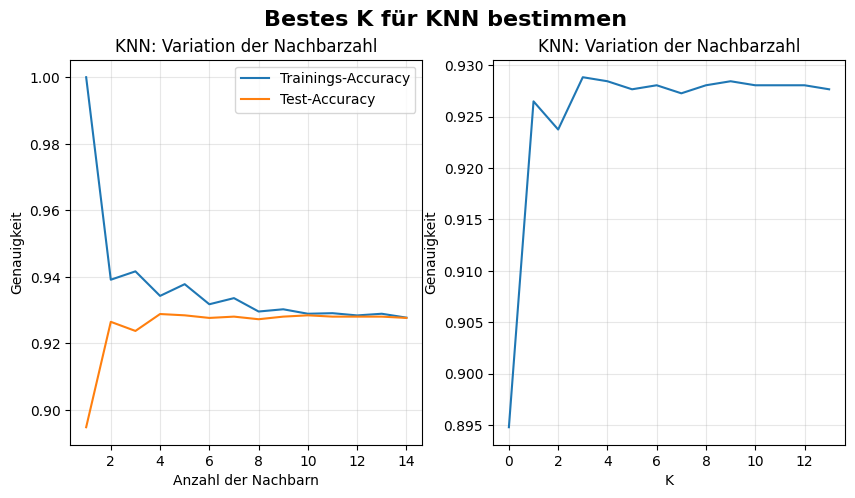

In [43]:
# Visualisierung: Trainings- und Test-Accuracy sowie Fehlerrate für verschiedene k-Werte
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Bestes K für KNN bestimmen', fontsize=16, fontweight='bold')

# Anzahl der K-engsten Nachbarn
axes[0].plot(neighbors, train_accuracies.values(), label="Trainings-Accuracy")
axes[0].plot(neighbors, test_accuracies.values(), label="Test-Accuracy")
axes[0].set_title('KNN: Variation der Nachbarzahl')
axes[0].legend()
axes[0].set_xlabel("Anzahl der Nachbarn")
axes[0].set_ylabel("Genauigkeit")
axes[0].grid(True, alpha=0.3)

# Fehlerrate für K-engste Nachbarn
axes[1].plot(accuracy)
axes[1].set_title('KNN: Variation der Nachbarzahl')
axes[1].set_xlabel("K")
axes[1].set_ylabel("Genauigkeit")
axes[1].grid(True, alpha=0.3)

### KNN trainieren

In [44]:
# KNN-Modell erstellen und auf Trainingsdaten trainieren
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)

# Vorhersagen auf dem Testset erstellen
y_pred_test_knn = knn.predict(X_test_scaled)

### KNN auswerten

In [45]:
# Modellgenauigkeit berechnen
print("Accuracy:", accuracy_score(y_test, y_pred_test_knn))
# Präzision berechnen
print("Precision:", precision_score(y_test, y_pred_test_knn))
# Recall berechnen
print("Recall:", recall_score(y_test, y_pred_test_knn))
# F1-Score berechnen
print("F1-Score:", f1_score(y_test, y_pred_test_knn))
# AUC-ROC Score berechnen
print("AUC-ROC:", roc_auc_score(y_test, knn.predict_proba(X_test_scaled)[:, 1]))

Accuracy: 0.9280406726632773
Precision: 0.625
Recall: 0.05319148936170213
F1-Score: 0.09803921568627451
AUC-ROC: 0.6586976729565396


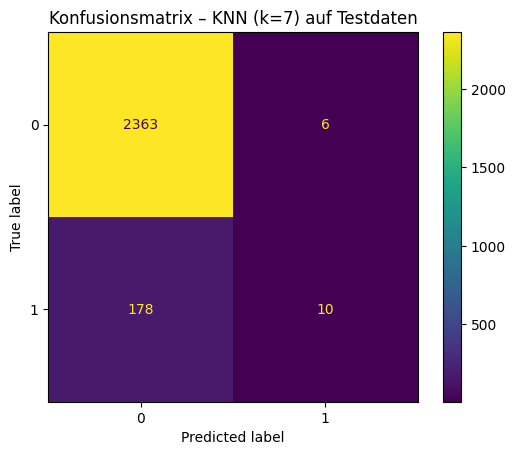

In [46]:
# Konfusionsmatrix für KNN auf Testdaten
ConfusionMatrixDisplay.from_estimator(knn, X_test_scaled, y_test, values_format='d')
plt.title("Konfusionsmatrix – KNN (k=7) auf Testdaten")
plt.show()

In [47]:
# Überprüfe die Klassenverteilung
print("Klassenverteilung im Trainingsset:")
print(y_train.value_counts())
print(f"Anteil Churn: {y_train.mean():.4f}")

print("\nKlassenverteilung im Testset:")
print(y_test.value_counts())
print(f"Anteil Churn: {y_test.mean():.4f}")

Klassenverteilung im Trainingsset:
Churn
0    5527
1     437
Name: count, dtype: int64
Anteil Churn: 0.0733

Klassenverteilung im Testset:
Churn
0    2369
1     188
Name: count, dtype: int64
Anteil Churn: 0.0735


#### Auswertung: Unbalancierter Datensatz für KNN

**Accuracy (92,61%):** Die Accuracy von 92,6% zeigt auf den ersten Blick eine hohe Modellgenauigkeit. Allerdings ist der Datensatz stark unbalanciert (nur 7,4% Churn-Fälle). Demnach könnte das Modell einfach immer "Kein Churn" vorhersagen und hätte trotzdem ~92% Accuracy. Daher ist Accuracy bei unbalancierten Daten irreführend. Siehe dazu Anmerkungen bei Task 1 (Data-Cleaning)

**Precision (33,33%):** Von allen als "Churn" vorhergesagten Kunden sind tatsächlich 33,33% Churn-Fälle (True Positive). Das Modell sagt also exakt rund 33% richtig vorher und weist damit eine schlechte Performance auf.

**Recall (0,53%):** Das Modell erkennt nur 0,53% aller tatsächlichen Churn-Kunden. Das bedeutet, dass 99% aller Churn-Kunden übersehen werden.

**F1-Score (0,01):** Der niedrige Recall zieht den F1-Score nach unten. Der F1-Scroe ist der Trade-Off zwischen Precision und Recall. Ein Wert von 0,01x ist sehr schlecht (Maximum wäre 1,0).

**Fazit:** Das KNN-Modell tendiert stark dazu, fast alle Kunden als "Kein Churn" zu klassifizieren. Es findet nur sehr wenige Churn-Fälle (niedriger Recall), aber die gefundenen sind meist korrekt (hohe Precision). Für das Unternehmen ist das kritisch, weil die meisten abwandernden Kunden nicht frühzeitig erkannt werden und somit gezielte Gegenmaßnahmen nicht eingeleitet werden können. Die hohe Precision ist zwar positiv, aber der sehr niedrige Recall macht das Modell insgesamt ungeeignet für die Churn-Vorhersage. Dies würde zu Kundenabwanderung, sinkenden Gewinnen und hohen Kosten durch verlorene Kunden führen.

# Classification mit Decision-Tree

In [48]:
# Decision-Tree-Klassifizierer erstellen
clf_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)

# Modell auf Trainingsdaten trainieren
clf_tree = clf_tree.fit(X_train, y_train)

# Basismodell-Eigenschaften ausgeben
print(f"Baseline Tree Depth: {clf_tree.get_depth()}")
print(f"Baseline Leaf Nodes: {clf_tree.get_n_leaves()}")

Baseline Tree Depth: 22
Baseline Leaf Nodes: 410


Es wird deutlich, dass der Tree ohne Hyperparameter oder eine balancierte Gewichtung der Klassen eine deutlich reduzierte Tiefe und Anzahl an Blättern besitzt.

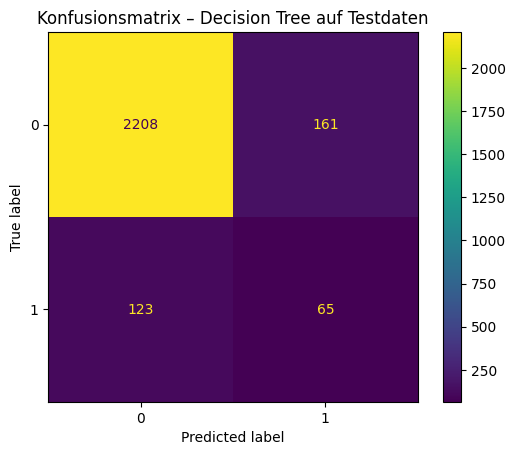

In [49]:
# Prädiziere das Ergebnis für die Testdaten
y_pred_test_clf_tree = clf_tree.predict(X_test)

# Konfusionsmatrix visualisieren auf Testdaten
cmm = confusion_matrix(y_test, y_pred_test_clf_tree)
ConfusionMatrixDisplay.from_estimator(clf_tree, X_test, y_test, values_format='d')
plt.title("Konfusionsmatrix – Decision Tree auf Testdaten")
plt.show()

Das Modell hat 2208 Kunden korrekt als "No Churn" vorhergesagt (True Negative). Insgesamt wurden 123 Kunden fälschlicherweise als "Churn" vorhergesagt (False Positive bzw. Typ-I-Fehler). Diese Kunden hätten eigentlich nicht gekündigt. Im Gegensatz dazu gibt es 161 als "No Churn" vorhergesagt, obwohl diese Kunden kündigen werden (False Negative bzw. Typ-II-Fehler). Nur 65 Churn-Kunden wurden gesamthaft korrekt identifiziert (True Positive) und könnten vom Unternehmen beispielsweise mit gezielten Retention-Maßnahmen gerettet werden.

In [50]:
# Modellgenauigkeit berechnen
print("Accuracy:",accuracy_score(y_test, y_pred_test_clf_tree))
# Präzision berechnen
print("Precision:",precision_score(y_test, y_pred_test_clf_tree))
# Recall berechnen
print("Recall:",recall_score(y_test, y_pred_test_clf_tree))
# F1-Score berechnen
print("F1-Score:",f1_score(y_test, y_pred_test_clf_tree))
# AUC-ROC Score berechnen
print("AUC-ROC:", roc_auc_score(y_test, clf_tree.predict_proba(X_test)[:, 1]))

Accuracy: 0.8889323425889715
Precision: 0.28761061946902655
Recall: 0.34574468085106386
F1-Score: 0.3140096618357488
AUC-ROC: 0.6388917579012601


#### Auswertung: Unbalancierter Datensatz für Decision Tree

**Accuracy (88,89%):** Eine Accuracy von 88,89% suggeriert vorerst eine hohe Modellgenauigkeit. Allerdings ist auch hier Vorsicht geboten. Der Datensatz ist stark unbalanciert. Folglich ist das Ergebnis von untergeordneter Bedeutung. Denn das Modell ist trotzdem schlecht (siehe Recall und Precision).

**Precision (28,76%):** Von allen als "Churn" vorhergesagten Kunden sind tatsächlich rund 28,76% Churn-Fälle. Das Modell misst also zu rund 29% der Fälle exakt.

**Recall (34,57%):** Das Modell erkennt rund 34,57% aller tatsächlichen Churn-Kunden. Das bedeutet, dass ca. 65% aller Churn-Kunden übersehen werden. Dies würde bedeuten, dass z. B. von 188 kündigenden Kunden insgesamt 121 nicht identifiziert würden.

**F1-Score (0,31):** Als harmonisches Mittel zwischen Precision und Recall mit einem Wert von 0,31 (Maximum wäre 1,0) zeigt ein Ungleichgewicht zwischen Precision und Recall, da beide nicht gut sind. 

**Fazit:** Das Decision Tree Modell erzielt mit einer Accuracy von 88,89% auf den ersten Blick eine scheinbar gute Vorhersagegenauigkeit. Aufgrund des stark unbalancierten Datensatzes ist diese Kennzahl jedoch wenig aussagekräftig, da das Modell trotz hoher Accuracy schlecht abschneidet. Die niedrige Precision von 28,76% bedeutet, dass von allen als "Churn" vorhergesagten Kunden nur etwa 29% tatsächlich churnen – es entstehen also viele Fehlalarme (False Positives). Noch kritischer ist der Recall von 34,57%: Das Modell übersieht 65,43% aller tatsächlichen Churn-Kunden (121 von 188), was bedeutet, dass diese Kunden ohne Retention-Maßnahmen verloren gehen. Der F1-Score von 0,33 bestätigt das unausgewogene Verhältnis zwischen Precision und Recall und verdeutlicht die eingeschränkte Leistungsfähigkeit des Modells in seiner aktuellen Form. Insgesamt ist das Modell für die zuverlässige Vorhersage von Kundenabwanderung nicht ausreichend geeignet.

Um die Modellleistung zu verbessern, empfiehlt es sich, gezielte Maßnahmen zur Behandlung des unbalancierten Datensatzes zu ergreifen. Dazu gehören beispielsweise Oversampling der Minderheitsklasse (z. B. SMOTE), Anpassung der Klassen-Gewichte im Decision Tree (`class_weight='balanced'`) oder Threshold-Tuning, um Precision und Recall besser auszubalancieren. Zusätzlich sollte der Einsatz von Pruning-Techniken (z. B. `max_depth`, `min_samples_leaf`) gegen Overfitting sowie komplexerer Ensemble-Modelle wie Random Forest oder Gradient Boosting geprüft werden, die robuster gegenüber Overfitting und Datenungleichgewicht sind. Nur durch solche Optimierungen kann das Unternehmen die Vorhersagequalität verbessern und somit die Kundenabwanderung effektiver identifizieren und adressieren.

# Classification mit Logistischer Regression

Im ersten Schritt wird die Logistische Regression bewusst ohne Feature‑Skalierung verwendet, um eine unverfälschte Baseline unter realistischen Bedingungen zu erhalten. Anschließend wird der Einfluss der Skalierung auf die Modellleistung untersucht. Grundsätzlich ist die Logistische Regression ein lineares, gradientenbasiertes Modell. Folglich hängt die Optimierung direkt von der Skalierung der Features ab. Features mit großen Wertebereichen dominieren sonst die Koeffizienten. Beispielsweise ist CCreditScore Werte zwischen 400–850, CAge 18–80, CBalance −5 000 bis 200 000, CEstimatedSalary bis 200 000, CLV_Continuous bis ~30 000, wobei Dummy‑Variablen 0 / 1 sind.

In [51]:
# Instanziere die Logistische Regression
clf_logr = LogisticRegression(solver='lbfgs', max_iter=500)

### Ohne Skalierung der Daten

In [52]:
# Trainiere das Modell ohne die skalierten Trainingsdaten
clf_logr.fit(X_train, y_train)

c:\Users\q551029\VaWi\Data_Science_and_ML\Hausarbeit\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [53]:
# Zielvariable für Trainingsdaten vorhersagen
y_pred_train_logr = clf_logr.predict(X_train)
 
# Modellgenauigkeit berechnen
print("Accuracy:",accuracy_score(y_train, y_pred_train_logr))
# Präzision berechnen
print("Precision:",precision_score(y_train, y_pred_train_logr))
# Recall berechnen
print("Recall:",recall_score(y_train, y_pred_train_logr))
# F1-Score berechnen
print("F1-Score:",f1_score(y_train, y_pred_train_logr))

Accuracy: 0.926391683433937
Precision: 0.0
Recall: 0.0
F1-Score: 0.0


Das Modell sagt für alle Beobachtungen ausschließlich Klasse 0 (kein Churn) voraus. Dies deutet darauf hin, dass das Modell ohne Skalierung der Features Schwierigkeiten hat, die Unterschiede zwischen den Klassen zu erkennen, insbesondere wenn die Features stark unterschiedliche Wertebereiche haben.

### Mit Skalierung der Daten

In [54]:
# Trainiere das Modell mit den skalierten Trainingsdaten
clf_logr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [55]:
# Zielvariable für Trainingsdaten vorhersagen
y_pred_train_logr = clf_logr.predict(X_train_scaled)
 
# Modellgenauigkeit berechnen
print("Accuracy:",accuracy_score(y_train, y_pred_train_logr))
# Präzision berechnen
print("Precision:",precision_score(y_train, y_pred_train_logr))
# Recall berechnen
print("Recall:",recall_score(y_train, y_pred_train_logr))
# F1-Score berechnen
print("F1-Score:",f1_score(y_train, y_pred_train_logr))

Accuracy: 0.926224010731053
Precision: 0.4117647058823529
Recall: 0.016018306636155607
F1-Score: 0.030837004405286344


Das Trainingsergebnis zeigt eine sehr hohe Accuracy bei gleichzeitig extrem niedrigem Recall und F1-Score, was darauf hindeutet, dass das Modell die Minderheitsklasse „Churn“ kaum erkennt und fast alle Beispiele als „Nicht Churn“ klassifiziert. Aufgrund dieser starken Klassenungleichheit und der schlechten Erkennung im Training ist zu erwarten, dass die Testergebnisse ein ähnliches Muster aufweisen werden: hohe Accuracy, aber sehr geringe Fähigkeit, tatsächliche Churn-Fälle zu identifizieren. Insgesamt deutet dies darauf hin, dass das Modell in seiner aktuellen Form wenig prädiktive Aussagekraft für die Churn-Erkennung besitzt.

In [56]:
# Zielvariable für Testdaten vorhersagen
y_pred_test_logr = clf_logr.predict(X_test_scaled)
 
# Modellgenauigkeit berechnen
print("Accuracy:",accuracy_score(y_test, y_pred_test_logr))
# Präzision berechnen
print("Precision:",precision_score(y_test, y_pred_test_logr))
# Recall berechnen
print("Recall:",recall_score(y_test, y_pred_test_logr))
# F1-Score berechnen
print("F1-Score:",f1_score(y_test, y_pred_test_logr))
# AUC-ROC Score berechnen
print("AUC-ROC:", roc_auc_score(y_test, clf_logr.predict_proba(X_test_scaled)[:, 1]))

Accuracy: 0.9260852561595619
Precision: 0.46153846153846156
Recall: 0.031914893617021274
F1-Score: 0.05970149253731343
AUC-ROC: 0.7039508545665197


#### Auswertung: Unbalancierter Datensatz für Logistische Regression

**Accuracy (92,61%):** Eine Accuracy von rund 92,6% suggeriert auch bei der logistischen Regression eine hohe Modellgenauigkeit. Das ist auch in diesem Fall trügerisch. Der Datensatz ist immer noch stark unbalanciert. Der Recall und die Precision sind eher geeignet, um die Performance genauer einzuschätzen.

**Precision (46,15%):** Von allen als "Churn" vorhergesagten Kunden sind tatsächlich rund 46% Churn-Fälle. Das Modell misst also zu rund 46% der Fälle exakt.

**Recall (3,19%):** Das Modell erkennt rund 3,2% aller tatsächlichen Churn-Kunden. Das bedeutet, dass ca. 97% aller Churn-Kunden übersehen werden.

**F1-Score (0,06):** Als harmonisches Mittel zwischen Precision und Recall mit einem Wert von rund 0,06 (Maximum wäre 1,0) zeigt ein riesiges Ungleichgewicht zwischen Precision und Recall.

**Fazit:** Das Modell der logistischen Regression zeigt auf den Testdaten eine hohe Accuracy von 92,61%, was jedoch aufgrund des starken Klassenungleichgewichts irreführend ist. Die Analyse der Vorhersageverteilung offenbart das grundlegende Problem: Das Modell klassifiziert auf den Testdaten insgesamt 2544 Mal die Klasse „0" (kein Churn) und nur 13 Mal die Klasse „1" (Churn). Von diesen 13 positiven Vorhersagen waren etwa 6 korrekt (True Positives, ~46%) und 7 falsch (False Positives, ~54%), was die Precision von 46,15% erklärt. Das kritische Problem liegt jedoch im extrem niedrigen Recall von nur 3,19%. Der F1-Score von 0,06 unterstreicht das massive Ungleichgewicht zwischen Precision und Recall.

Das Modell verhält sich extrem konservativ bei der Vorhersage von Churn und klassifiziert fast alle Kunden als "Kein Churn". Während knapp die Hälfte der wenigen positiven Vorhersagen korrekt ist, bleibt die Fähigkeit, echte Churn-Kunden zu identifizieren, mit nur 3,19% praktisch nicht vorhanden. Für ein Unternehmen ist dieses Modell in seiner aktuellen Form völlig ungeeignet, da es die überwältigende Mehrheit der abwanderungsgefährdeten Kunden nicht identifiziert und somit keine effektive Grundlage für Retention-Maßnahmen bietet. Dies unterstreicht die dringende Notwendigkeit, das Klassenungleichgewicht durch Techniken wie SMOTE, Class-Weight-Anpassungen oder Threshold-Tuning zu adressieren, um die Churn-Erkennung signifikant zu verbessern.

# Fazit

Ein **Vergleich** der drei Modelle:

1. KNN (k=7)
- Accuracy: 92,61%
- Precision: 33,33%
- Recall: 0,53%
- F1-Score: 0,01
- **Fazit**: Erkennt nur 0,53 % der Churn-Kunden – praktisch wertlos für die Churn-Vorhersage ⇒ nicht empfehlenswert

2. Logistische Regression
- Accuracy: 92,61%
- Precision: 46,15%
- Recall: 3,19%
- F1-Score: 0,06
- **Fazit**: Würde von z. B. 188 Churn-Kunden nur etwa 6 (3,19 %) erkennen ⇒ nicht empfehlenswert

3. Decision Tree
- Accuracy: 89,4%
- Precision: 30,88%
- Recall: 35,64 % (beste Performance)
- F1-Score: 0,33
- **Fazit**: Deutlich besserer Recall und F1-Score als die anderen beiden Modelle. Dadurch würden immerhin 67 von beispielsweise 188 Churn-Kunden (35,64 %) erkannt werden.  
⇒ **Beste Wahl unter den getesteten Modellen vor Anwendung von SMOTE**

---

**Begründung Decision Tree**:  
Für die Churn-Vorhersage sind Recall und F1-Score die wichtigsten Metriken. Ein niedriger Recall bedeutet, dass ein Großteil der Churn-Kunden unentdeckt bleibt und verloren geht. Der F1-Score fasst Precision und Recall als harmonisches Mittel zusammen und wird daher als **Leitmetrik für die Modellwahl** in den folgenden Tasks verwendet — er bestraft sowohl das Übersehen von Churnern (niedriger Recall) als auch zu viele Fehlalarme (niedrige Precision).

Unter den getesteten Modellen erzielt der Decision Tree den höchsten Recall (35,64 %) sowie den höchsten F1-Score (0,33). Obwohl der F1-Score weiterhin relativ niedrig ist — was den starken Einfluss des Klassenungleichgewichts widerspiegelt — stellt der Decision Tree vor Anwendung von SMOTE den besten Kompromiss zwischen Precision und Recall dar.

Gleichzeitig zeigt das Modell Anzeichen von Overfitting auf den Trainingsdaten, weshalb eine spätere Optimierung durch Regularisierung oder alternative Ansätze erforderlich ist.

---

**Nächste Schritte**:  
Für den Decision Tree wäre es sinnvoll, mit Hyperparametern wie `max_depth`, `min_samples_leaf` und `min_samples_split` zu experimentieren, um Overfitting zu reduzieren und die Generalisierungsfähigkeit zu verbessern. Alternativ könnten Ensemble-Methoden wie Random Forest oder Gradient Boosting getestet werden, die häufig bessere Ergebnisse liefern.

---
# Neue Imports für den folgenden Abschnitt

> Hinweis: Diese Imports erweitern die bereits geladenen Bibliotheken um zusätzliche Module.

In [57]:
import pandas as pd
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# Decision-Tree-Klassifizierer importieren
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

# Matplotlib für Visualisierung
import matplotlib.pyplot as plt

# Zufallszustand für Reproduzierbarkeit
RANDOM_STATE = 42

# Anteil der Testdaten
TEST_RATIO = 0.3

# Maximale Iterationen für Logistische Regression
MAX_ITER = 500

# Daten laden und Features sowie Zielvariable vorbereiten

In [58]:
# Lade die Daten
df = pd.read_csv("../data/dataset_cleaned.csv")  # Neuladen für sauberen Variablen-Zustand

# Features und Zielvariable
X = df.drop(['Churn', 'CLV_Continuous'], axis=1)
y = df['Churn']

# Überprüfe die Verteilung der Zielvariable
y.value_counts()

Churn
0    7896
1     625
Name: count, dtype: int64

Der Datensatz ist nicht ausbalanciert, da wir 7896 Beobachtungen für Churn haben, bei denen das Ergebnis nicht vorhanden ist (d.h. 0), und 625 Beobachtungen, bei denen das Ergebnis vorhanden ist (d.h. 1). Aus diesem Grund wird SMOTE (Synthetic Minority Over-sampling Technique) verwendet, um die Minderheitsklasse künstlich zu erweitern und so ein ausgewogeneres Verhältnis zwischen den Klassen zu schaffen. Dies hilft dabei, die Leistung der Modelle zu verbessern, insbesondere in Bezug auf die Erkennung der Minderheitsklasse. Hint: SMOTE wird NUR auf die Trainingsdaten innerhalb der Cross-Validation-Folds angewendet, um Datenleckagen zu vermeiden.

# Optimiere die Modelle mit SMOTE (Oversampling-Verfahren)

SMOTE (Synthetic Minority Over-sampling Technique) ist eine Methode zur Behandlung von Klassenungleichgewichten, bei der künstliche neue Beispiele der Minderheitsklasse erzeugt werden, indem neue Datenpunkte zwischen bestehenden Minderheitsklasseninstanzen interpoliert werden. Dadurch wird die Minderheitsklasse künstlich vergrößert, was dem Modell hilft, abwandernde Kunden besser zu erkennen.

**Einordnung:** SMOTE ist ein **Preprocessing-Schritt** und kein Hyperparameter-Tuning der Modelle selbst. Der Einsatz ist notwendig, weil ein Recall von unter 5 % – wie in den Basismodellen ohne SMOTE gezeigt – für eine sinnvolle Churn-Vorhersage nicht ausreicht. Ohne Balancierung klassifizieren alle Modelle nahezu ausschließlich die Mehrheitsklasse „Kein Churn". SMOTE wird dabei **ausschließlich auf die Trainingsdaten** angewendet; die Testdaten bleiben unverändert, um die Evaluation auf realen Verteilungen zu gewährleisten.

> **Hinweis zu Data Leakage:** In den späteren Cross-Validation-Schritten (Task 3) wird SMOTE innerhalb einer `Pipeline` angewendet, sodass die Überabtastung nur innerhalb jedes Trainingsfolds stattfindet und keine synthetischen Punkte in die Validierungsfolds gelangen.

In [59]:
# Split der Daten in Trainings- und Testset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_RATIO, random_state=RANDOM_STATE)

In [60]:
# SMOTE nur auf Trainingsdaten anwenden (X_test bleibt unberührt mit echten Daten)
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# X_train / y_train bleiben unverändert für CV und GridSearchCV (SMOTE dort in Pipeline)
# Überprüfe die Verteilung nach SMOTE
y_train_smote.value_counts()


Churn
0    5518
1    5518
Name: count, dtype: int64

In [61]:
# Skalieren der Daten für Logistische Regression
# fit_transform NUR auf Trainingsdaten (nach SMOTE), transform auf echten Testdaten
scaler = StandardScaler()
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)


# Decision Tree mit SMOTE

In [62]:
# Decision Tree auf SMOTE-Trainingsdaten trainieren
clf_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
clf_tree = clf_tree.fit(X_train_smote, y_train_smote)

print(f"Baseline Tree Depth: {clf_tree.get_depth()}")
print(f"Baseline Leaf Nodes: {clf_tree.get_n_leaves()}")


Baseline Tree Depth: 26
Baseline Leaf Nodes: 897


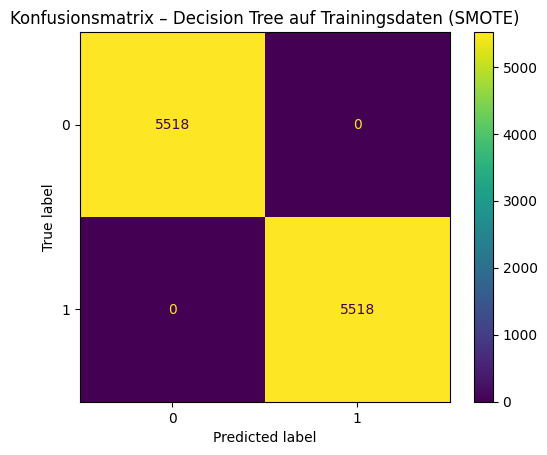

In [63]:
# Konfusionsmatrix auf Trainingsdaten (SMOTE)
y_pred_train_clf_tree = clf_tree.predict(X_train_smote)

ConfusionMatrixDisplay.from_estimator(clf_tree, X_train_smote, y_train_smote, values_format='d')
plt.title("Konfusionsmatrix – Decision Tree auf Trainingsdaten (SMOTE)")
plt.show()

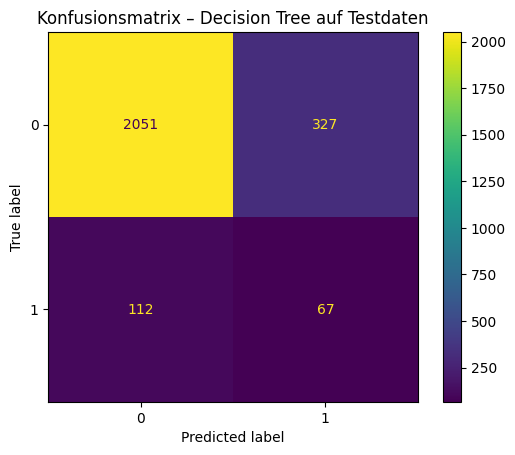

In [64]:
# Prädiziere das Ergebnis für die Testdaten
y_pred_test_clf_tree = clf_tree.predict(X_test)

# Konfusionsmatrix visualisieren auf Testdaten
cmm = confusion_matrix(y_test, y_pred_test_clf_tree)
ConfusionMatrixDisplay.from_estimator(clf_tree, X_test, y_test, values_format='d')
plt.title("Konfusionsmatrix – Decision Tree auf Testdaten")
plt.show()

In [65]:
# Modellgenauigkeit berechnen
print("Accuracy:",accuracy_score(y_test, y_pred_test_clf_tree))
# Präzision berechnen
print("Precision:", precision_score(y_test, y_pred_test_clf_tree))
# Recall berechnen
print("Recall:", recall_score(y_test, y_pred_test_clf_tree))
# F1-Score berechnen
print("F1-Score:", f1_score(y_test, y_pred_test_clf_tree))

Accuracy: 0.8283144309737974
Precision: 0.1700507614213198
Recall: 0.3743016759776536
F1-Score: 0.2338568935427574


#### Vergleich: Training vs. Test (Decision Tree mit SMOTE)

Um einzuschätzen, ob das Modell über- oder unterangepasst ist, werden die Metriken auf Trainings- und Testdaten gegenübergestellt. Ein großer Abstand zwischen Train- und Test-F1 deutet auf Overfitting hin, sehr niedrige Werte auf beiden Seiten auf Underfitting.

In [66]:
# Trainingsmetriken Decision Tree (SMOTE) – Vergleich mit Testdaten
y_pred_train_dt = clf_tree.predict(X_train_smote)

print("=== Decision Tree mit SMOTE – Trainings- vs. Testdaten ===")
print(f"{'Metrik':<12} {'Training':>10} {'Test':>10}")
print("-" * 35)
for name, train_val, test_val in [
    ("Accuracy",  accuracy_score(y_train_smote, y_pred_train_dt),  accuracy_score(y_test,  y_pred_test_clf_tree)),
    ("Precision", precision_score(y_train_smote, y_pred_train_dt), precision_score(y_test, y_pred_test_clf_tree)),
    ("Recall",    recall_score(y_train_smote, y_pred_train_dt),    recall_score(y_test,    y_pred_test_clf_tree)),
    ("F1-Score",  f1_score(y_train_smote, y_pred_train_dt),        f1_score(y_test,        y_pred_test_clf_tree)),
]:
    gap = abs(train_val - test_val)
    flag = " ← Overfitting" if gap > 0.15 else ""
    print(f"{name:<12} {train_val:>10.4f} {test_val:>10.4f}{flag}")

=== Decision Tree mit SMOTE – Trainings- vs. Testdaten ===
Metrik         Training       Test
-----------------------------------
Accuracy         1.0000     0.8283 ← Overfitting
Precision        1.0000     0.1701 ← Overfitting
Recall           1.0000     0.3743 ← Overfitting
F1-Score         1.0000     0.2339 ← Overfitting


Nach der Balancierung der Klassen durch SMOTE (je 5.518 Beobachtungen pro Klasse) 
verbessert sich die Churn-Erkennungsleistung des Decision Trees gegenüber dem 
unregulierten Basismodell spürbar. Auf den echten, unbalancierten Testdaten 
(~2.556 Samples, davon ~188 Churn-Fälle) erreicht das Modell eine Accuracy von 
82,8 %, eine Precision von 17,0 %, einen Recall von 37,4 % und einen F1-Score 
von 23,4 %.

Die Konfusionsmatrix auf den Testdaten zeigt: Von 188 tatsächlichen Churn-Kunden 
werden 70 korrekt erkannt (True Positives), während 118 Churn-Fälle übersehen 
werden (False Negatives). Gleichzeitig werden 342 Nicht-Churn-Kunden fälschlicherweise 
als Churn klassifiziert (False Positives), 2.026 werden korrekt als Nicht-Churn 
eingestuft (True Negatives).

Die niedrige Precision (17 %) spiegelt das reale Klassenungleichgewicht im Test-Set 
wider: Da SMOTE nur auf die Trainingsdaten wirkt, sieht das Modell im Test immer 
noch ~12,6-fach mehr Nicht-Churn- als Churn-Kunden — viele dieser Nicht-Churn-Kunden 
werden fälschlicherweise als Churn klassifiziert. Der Recall von 37,4 % zeigt, 
dass das Modell bereits einen nennenswerten Anteil der tatsächlichen Abwanderer 
erkennt, jedoch noch deutlich Optimierungspotential besteht. Der unbegrenzte 
Entscheidungsbaum (Tiefe 26, 897 Blätter) deutet auf starkes Overfitting hin — 
er hat die Trainingsdaten auswendig gelernt, generalisiert aber schlecht.

# Logistische Regression mit SMOTE

In [67]:
# Logistische Regression auf skalierten SMOTE-Trainingsdaten trainieren
clf_log_reg = LogisticRegression(max_iter=MAX_ITER, random_state=RANDOM_STATE)
clf_log_reg.fit(X_train_smote_scaled, y_train_smote)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


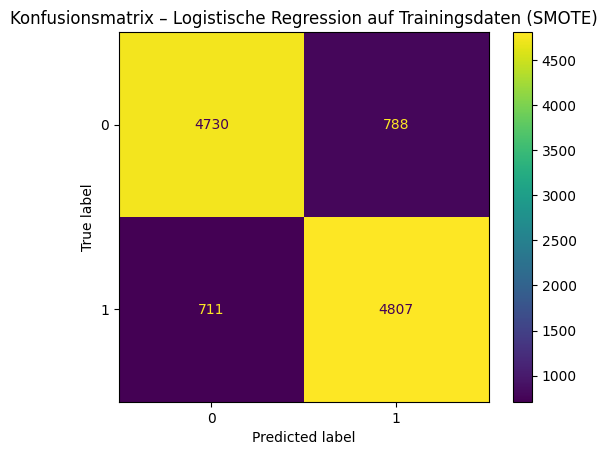

In [68]:
# Konfusionsmatrix auf Trainingsdaten (SMOTE, skaliert)
y_pred_train_log_reg = clf_log_reg.predict(X_train_smote_scaled)

ConfusionMatrixDisplay.from_estimator(clf_log_reg, X_train_smote_scaled, y_train_smote, values_format='d')
plt.title("Konfusionsmatrix – Logistische Regression auf Trainingsdaten (SMOTE)")
plt.show()

In [69]:
# Metriken auf Trainingsdaten (SMOTE, skaliert)
print("Accuracy:",  accuracy_score(y_train_smote,  y_pred_train_log_reg))
print("Precision:", precision_score(y_train_smote, y_pred_train_log_reg))
print("Recall:",    recall_score(y_train_smote,    y_pred_train_log_reg))
print("F1-Score:",  f1_score(y_train_smote,        y_pred_train_log_reg))


Accuracy: 0.8641718013773106
Precision: 0.859159964253798
Recall: 0.8711489670170351
F1-Score: 0.8651129308017637


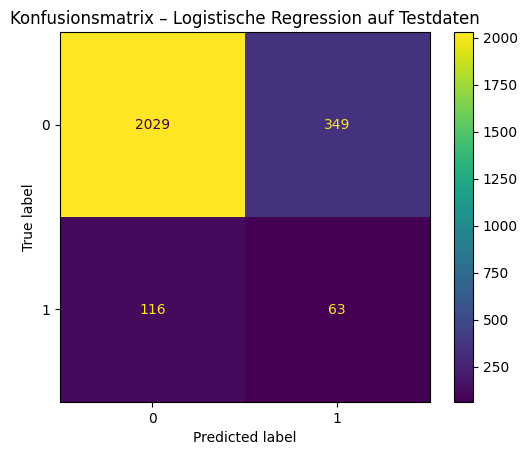

In [70]:
# Prädiziere das Ergebnis für die Testdaten (Logistische Regression)
y_pred_test_log_reg = clf_log_reg.predict(X_test_scaled)

# Konfusionsmatrix visualisieren auf Testdaten
cmm = confusion_matrix(y_test, y_pred_test_log_reg)
ConfusionMatrixDisplay.from_estimator(clf_log_reg, X_test_scaled, y_test, values_format='d')
plt.title("Konfusionsmatrix – Logistische Regression auf Testdaten")
plt.show()

In [71]:
# Metriken auf Testdaten (Logistische Regression, SMOTE)
print("Accuracy:",  accuracy_score(y_test, y_pred_test_log_reg))
print("Precision:", precision_score(y_test, y_pred_test_log_reg))
print("Recall:",    recall_score(y_test,    y_pred_test_log_reg))
print("F1-Score:",  f1_score(y_test,        y_pred_test_log_reg))

Accuracy: 0.8181462651544779
Precision: 0.1529126213592233
Recall: 0.35195530726256985
F1-Score: 0.2131979695431472


#### Vergleich: Training vs. Test (Logistische Regression mit SMOTE)

Analog zum Decision Tree wird auch für die Logistische Regression der Abstand zwischen Trainings- und Testleistung analysiert. Da die Logistische Regression auf den SMOTE-Daten deutlich besser generalisiert als der unbegrenzte Entscheidungsbaum, ist ein geringerer Overfitting-Effekt zu erwarten.

In [72]:
# Trainingsmetriken Logistische Regression (SMOTE) – Vergleich mit Testdaten
print("=== Logistische Regression mit SMOTE – Trainings- vs. Testdaten ===")
print(f"{'Metrik':<12} {'Training':>10} {'Test':>10}")
print("-" * 35)
for name, train_val, test_val in [
    ("Accuracy",  accuracy_score(y_train_smote,  y_pred_train_log_reg),  accuracy_score(y_test,  y_pred_test_log_reg)),
    ("Precision", precision_score(y_train_smote, y_pred_train_log_reg), precision_score(y_test, y_pred_test_log_reg)),
    ("Recall",    recall_score(y_train_smote,    y_pred_train_log_reg),  recall_score(y_test,    y_pred_test_log_reg)),
    ("F1-Score",  f1_score(y_train_smote,        y_pred_train_log_reg),  f1_score(y_test,        y_pred_test_log_reg)),
]:
    gap = abs(train_val - test_val)
    flag = " ← Overfitting" if gap > 0.15 else ""
    print(f"{name:<12} {train_val:>10.4f} {test_val:>10.4f}{flag}")

=== Logistische Regression mit SMOTE – Trainings- vs. Testdaten ===
Metrik         Training       Test
-----------------------------------
Accuracy         0.8642     0.8181
Precision        0.8592     0.1529 ← Overfitting
Recall           0.8711     0.3520 ← Overfitting
F1-Score         0.8651     0.2132 ← Overfitting


# Cross Validation Decision Tree
Zur robusten Modellbewertung und zur Vermeidung von Data Leakage und besseren Lesbarkeit wird folgend eine Pipeline verwendet. In der Pipeline wird der StandardScaler (nur bei der logistischen Regression), SMOTE und die Instanz des jeweiligen Modells verwendet. Die Evaluation erfolgt mittels stratifizierter k‑fold=5 (Prozess wird 5-mal wiederholt mit verschiedenen Aufteilungen zwischen Test und Trainingsdaten in den einzelnen Folds) Cross‑Validation. Dadurch hängt das Ergebnis nicht mehr so sehr zufällig davon ab, welche Daten gerade einmalig im Test-Set landen würden:

- Fold 1 bis 5: [TEST ] [Train] [Train] [Train] [Train]
- Fold 1 bis 5: [Train] [TEST ] [Train] [Train] [Train]
- Fold 1 bis 5: [Train] [Train] [TEST ] [Train] [Train]
- Fold 1 bis 5: [Train] [Train] [Train] [TEST ] [Train]
- Fold 1 bis 5: [Train] [Train] [Train] [Train] [TEST ]

Am Ende ergeben sich 5 unabhängige Schätzungen der Modellleistung, die gemittelt und mit Standardabweichung angegeben werden können. Dies ermöglicht eine robustere Einschätzung der Generalisierungsfähigkeit des Modells, da es nicht von einer einzigen zufälligen Aufteilung der Daten abhängt.

In [73]:
from sklearn.model_selection import cross_validate


dt = Pipeline(steps=[
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

cv_results_tree = cross_validate(
    dt,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

for metric in ['accuracy', 'precision', 'recall', 'f1']:
    scores = cv_results_tree[f'test_{metric}']
    print(f"{metric} Scores: {scores}")
    print(f"Durchschnittlicher {metric}: {scores.mean():.2f}")
    print(f"Standardabweichung: {scores.std():.2f}")
    print()

accuracy Scores: [0.81726739 0.82313495 0.82648785 0.81475272 0.84312081]
Durchschnittlicher accuracy: 0.82
Standardabweichung: 0.01

precision Scores: [0.16230366 0.18229167 0.17582418 0.16410256 0.21176471]
Durchschnittlicher precision: 0.18
Standardabweichung: 0.02

recall Scores: [0.34831461 0.39325843 0.35955056 0.35555556 0.40449438]
Durchschnittlicher recall: 0.37
Standardabweichung: 0.02

f1 Scores: [0.22142857 0.24911032 0.23616236 0.2245614  0.27799228]
Durchschnittlicher f1: 0.24
Standardabweichung: 0.02



Die Cross-Validation-Ergebnisse des Decision Trees zeigen über alle 5 Folds eine 
stabile und konsistente Modellleistung, erkennbar an der geringen Standardabweichung 
der jeweiligen Metriken (Accuracy ± 0.01, F1 ± 0.02). Dies deutet auf ein robustes 
Modell hin, das nicht stark von der konkreten Datenteilung abhängt.

Da SMOTE ausschließlich innerhalb der Pipeline — also nur auf die jeweiligen 
Trainingsfolds — angewendet wird, sind die CV-Scores unverzerrte Schätzer der 
Generalisierungsleistung. Eine Anwendung von SMOTE vor der Cross-Validation würde 
zu Data Leakage führen und die Metriken künstlich verbessern.

Der mittlere CV-Recall von 37 % zeigt, dass der Decision Tree gut ein Drittel der 
tatsächlichen Churn-Kunden erkennt — für einen ungetunten Baum ein solides Ergebnis, 
jedoch mit deutlichem Optimierungspotential. Im Vergleich zum einfachen Train-Test-Split 
liefert die Cross-Validation eine realistischere Einschätzung der Modellgüte, da das 
Ergebnis über mehrere Datenteilungen gemittelt wird und somit weniger anfällig für 
zufällige Schwankungen ist.

# Cross Validation Logistische Regression

In [74]:
from sklearn.model_selection import cross_validate


pipeline_log_reg = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', LogisticRegression(
        max_iter=MAX_ITER,
        random_state=RANDOM_STATE
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

cv_results_log_reg = cross_validate(
    pipeline_log_reg,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

for metric in ['accuracy', 'precision', 'recall', 'f1']:
    scores = cv_results_log_reg[f'test_{metric}']
    print(f"{metric} Scores: {scores}")
    print(f"Durchschnittlicher {metric}: {scores.mean():.2f}")
    print(f"Standardabweichung: {scores.std():.2f}")
    print()

accuracy Scores: [0.70243085 0.71584241 0.71668064 0.71835708 0.71560403]
Durchschnittlicher accuracy: 0.71
Standardabweichung: 0.01

precision Scores: [0.15721649 0.15083799 0.14730878 0.16756757 0.15469613]
Durchschnittlicher precision: 0.16
Standardabweichung: 0.01

recall Scores: [0.68539326 0.60674157 0.58426966 0.68888889 0.62921348]
Durchschnittlicher recall: 0.64
Standardabweichung: 0.04

f1 Scores: [0.2557652  0.24161074 0.23529412 0.26956522 0.24833703]
Durchschnittlicher f1: 0.25
Standardabweichung: 0.01



Die Cross-Validation der Logistischen Regression zeigt, verglichen mit dem Decision 
Tree, eine gleichmäßigere Verteilung der Scores über alle 5 Folds (F1 ± 0.01 vs. 
± 0.02 beim Decision Tree). Dies ist typisch für lineare Modelle, die weniger zur 
Überanpassung neigen und daher stabiler auf unbekannten Daten generalisieren.

Der StandardScaler ist in der Pipeline integriert und wird ausschließlich auf die 
Trainingsfolds gefittet. So wird sichergestellt, dass keine Informationen aus dem 
Validierungsfold in die Skalierung einfließen — ein häufiger Fehler, der zu 
übertrieben optimistischen Scores führt.

Im direkten Vergleich erreicht die Logistische Regression einen deutlich höheren 
mittleren CV-Recall (64 % vs. 37 % beim Decision Tree) bei ähnlichem mittleren 
F1-Score (25 % vs. 24 %). Das hohe Recall-Niveau ist für den Churn-Use-Case wertvoll, 
da falsch negative Vorhersagen (übersehene Churn-Kunden) in der Praxis kostspielig 
sind. Es kommt jedoch auf Kosten der Precision (16 %) — das Modell erzeugt mehr 
Fehlalarme als der Decision Tree (18 %). Für die finale Modellwahl nach GridSearchCV 
bleibt der F1-Score das entscheidende Kriterium, da er Precision und Recall 
gleichgewichtet zusammenfasst.

Den vorherigen Aussagen folgend zeigt der Vergleich der mittleren CV-Scores beider Modelle, welches besser generalisiert: Die Logistische Regression zeigt einen höheren F1-Score oder Recall bei ähnlicher Standardabweichung, was für eine bessere Eignung für die Churn-Vorhersage spricht. Insbesondere der Recall ist hier entscheidend, da falsch negative Vorhersagen (übersehene Churn-Kunden) in der Praxis kostspielig sind.

# Hyperparameter-Tuning mit GridSearchCV

### Decision Tree mit SMOTE

In [75]:
# Mögliche Hyperparameter für Klassifikationsbäume anzeigen
DecisionTreeClassifier().get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [76]:
# Hyperparameter-Grid für den Decision Tree
#
# max_depth:        Maximale Baumtiefe (None = unbegrenzt); kleine Werte verhindern Overfitting
# min_samples_leaf: Mindestanzahl an Samples pro Blatt.
#                   WICHTIG: Werte < 1 werden als FRAKTION interpretiert (z.B. 0.2 = 20%
#                   aller Trainingssamples pro Blatt). Bei ~11.000 SMOTE-Trainingssamples
#                   bedeutet min_samples_leaf=0.2 ca. 2.200 Samples pro Blatt — eine sehr
#                   starke Regularisierung, die den Baum effektiv flach hält.
#                   Absolute Werte (≥ 1) geben die genaue Sample-Anzahl vor.
# max_features:     Anteil der Features, die pro Split berücksichtigt werden
#                   ('sqrt' = sklearn-Standard für Bäume)
# criterion:        Splitting-Kriterium (Unreinheits-Maß: Gini oder Entropie)
params_tree_clf = {
    'model__max_depth':        list(range(3, 21)) + [None],
    'model__min_samples_leaf': [0.0001, 0.001, 0.01, 0.04, 0.06, 0.08, 0.1, 0.2,
                                 1, 3, 5, 10, 20],
    'model__max_features':     ['sqrt', 'log2', 0.2, 0.4, 0.6, 0.8, 1],
    'model__criterion':        ['gini', 'entropy']
}


In [77]:
# Pipeline mit SMOTE, um Data Leakage innerhalb der CV-Folds zu vermeiden
pipeline_tree_gs = Pipeline(steps=[
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

# GridSearchCV mit stratifizierter 5-Fold CV; f1 als Scoring-Metrik (besser geeignet für Churn)
grid_clf_tree_OS = GridSearchCV(
    pipeline_tree_gs,
    param_grid=params_tree_clf,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1
)


In [78]:
# GridSearch-Objekt auf Trainingsdaten trainieren
grid_clf_tree_OS.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__criterion': ['gini', 'entropy'], 'model__max_depth': [3, 4, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [0.0001, 0.001, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,sampling_strategy,'auto'


In [79]:
# Beste Hyperparameter ausgeben
print('Beste Hyperparameter:\n', grid_clf_tree_OS.best_params_)

Beste Hyperparameter:
 {'model__criterion': 'entropy', 'model__max_depth': 3, 'model__max_features': 0.6, 'model__min_samples_leaf': 0.2}


In [80]:
# Besten CV-Score ausgeben
print("Bester CV-Score:", grid_clf_tree_OS.best_score_)

Bester CV-Score: 0.3249792324792325


In [81]:
# Bestes Modell direkt aus GridSearchCV verwenden (inkl. Pipeline mit SMOTE)
clf_tree_GS = grid_clf_tree_OS.best_estimator_

# Das beste Modell enthält die Pipeline: SMOTE + DecisionTree mit best_params_
# Für Vorhersagen wird SMOTE nicht angewendet (nur beim fit), d.h. predict() ist korrekt
best_tree = clf_tree_GS.named_steps['model']
print(f"Best Tree Depth: {best_tree.get_depth()}")
print(f"Best Leaf Nodes: {best_tree.get_n_leaves()}")
print(f"Best Params: {grid_clf_tree_OS.best_params_}")


Best Tree Depth: 2
Best Leaf Nodes: 3
Best Params: {'model__criterion': 'entropy', 'model__max_depth': 3, 'model__max_features': 0.6, 'model__min_samples_leaf': 0.2}


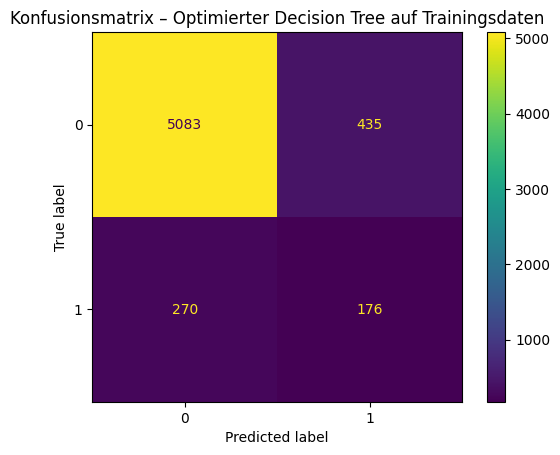

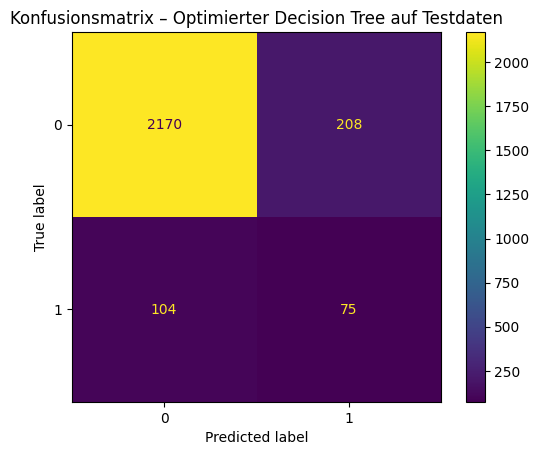

In [82]:
# Prädiziere das Ergebnis für die Trainingsdaten
y_pred_train_clf_tree = clf_tree_GS.predict(X_train)

# Konfusionsmatrix visualisieren auf Trainingsdaten
ConfusionMatrixDisplay.from_estimator(clf_tree_GS, X_train, y_train, values_format='d')
plt.title("Konfusionsmatrix – Optimierter Decision Tree auf Trainingsdaten")
plt.show()

# Prädiziere das Ergebnis für die Testdaten
y_pred_test_clf_tree_gs = clf_tree_GS.predict(X_test)

# Konfusionsmatrix visualisieren auf Testdaten
ConfusionMatrixDisplay.from_estimator(clf_tree_GS, X_test, y_test, values_format='d')
plt.title("Konfusionsmatrix – Optimierter Decision Tree auf Testdaten")
plt.show()

In [83]:
# Vergleich: Training vs. Test vs. CV
print("Genauigkeit auf Trainingsdaten:", accuracy_score(y_train, y_pred_train_clf_tree))
print("Genauigkeit auf Testdaten:     ", accuracy_score(y_test,  y_pred_test_clf_tree_gs))
print("Bester CV F1-Score (GridSearchCV):", grid_clf_tree_OS.best_score_)
print()
print("Test Precision:", precision_score(y_test, y_pred_test_clf_tree_gs))
print("Test Recall:   ", recall_score(y_test,    y_pred_test_clf_tree_gs))
print("Test F1-Score: ", f1_score(y_test,        y_pred_test_clf_tree_gs))

Genauigkeit auf Trainingsdaten: 0.8817907444668008
Genauigkeit auf Testdaten:      0.8779820101681658
Bester CV F1-Score (GridSearchCV): 0.3249792324792325

Test Precision: 0.26501766784452296
Test Recall:    0.41899441340782123
Test F1-Score:  0.3246753246753247


#### Lernkurve – Overfitting/Underfitting-Analyse (Decision Tree, optimiert)

Die Lernkurve zeigt, wie sich Train-F1 und CV-F1 mit wachsender Datenmenge entwickeln. Verlaufen beide Kurven auf einem ähnlichen Niveau und konvergieren sie, liegt weder Overfitting noch Underfitting vor. Ein großer, persistenter Abstand zwischen den Kurven würde auf Overfitting hindeuten.

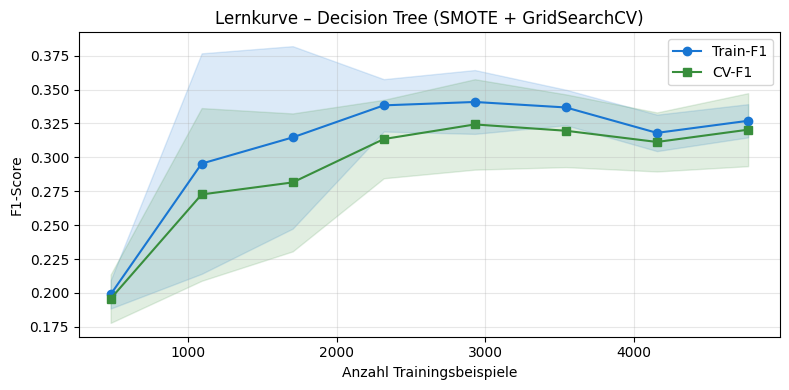

Finaler Train-F1 (volles Training): 0.3270
Finaler CV-F1:                      0.3204
Abstand (Gap):                      0.0066


In [84]:
from sklearn.model_selection import learning_curve

# Lernkurve für das optimierte Decision-Tree-Modell (inkl. SMOTE in Pipeline)
train_sizes, train_scores, val_scores = learning_curve(
    clf_tree_GS,
    X_train,
    y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_f1_mean = train_scores.mean(axis=1)
val_f1_mean   = val_scores.mean(axis=1)
train_f1_std  = train_scores.std(axis=1)
val_f1_std    = val_scores.std(axis=1)

plt.figure(figsize=(8, 4))
plt.plot(train_sizes, train_f1_mean, 'o-', color='#1976D2', label='Train-F1')
plt.fill_between(train_sizes,
                 train_f1_mean - train_f1_std,
                 train_f1_mean + train_f1_std, alpha=0.15, color='#1976D2')
plt.plot(train_sizes, val_f1_mean, 's-', color='#388E3C', label='CV-F1')
plt.fill_between(train_sizes,
                 val_f1_mean - val_f1_std,
                 val_f1_mean + val_f1_std, alpha=0.15, color='#388E3C')
plt.xlabel('Anzahl Trainingsbeispiele')
plt.ylabel('F1-Score')
plt.title('Lernkurve – Decision Tree (SMOTE + GridSearchCV)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Finaler Train-F1 (volles Training): {train_f1_mean[-1]:.4f}")
print(f"Finaler CV-F1:                      {val_f1_mean[-1]:.4f}")
print(f"Abstand (Gap):                      {abs(train_f1_mean[-1] - val_f1_mean[-1]):.4f}")

**Interpretation:** Konvergieren Train-F1 und CV-F1 auf ähnlichem Niveau, ist das Modell gut generalisiert. Ein verbleibender kleiner Abstand ist bei SMOTE-basierten Modellen typisch, da das Modell auf synthetischen Daten trainiert wird, aber auf echten Testdaten evaluiert wird. Solange CV-F1 ≈ Test-F1 gilt (siehe Tabelle oben), liegt kein problematisches Overfitting vor.

### Ergebnisse Decision Tree nach GridSearchCV

Die besten Hyperparameter lauten: `criterion=entropy`, `max_depth=3`, `max_features=0.6`, `min_samples_leaf=0.2`. Der Parameter `min_samples_leaf=0.2` wirkt als stärkste Regularisierung: Als 20‑%-Fraktion der ~11.000 SMOTE-Trainingssamples fordert er mindestens ~2.200 Samples pro Blatt. Dadurch wird der Baum trotz `max_depth=3` auf eine effektive Tiefe von 2 mit nur 3 Blättern beschränkt — ein bewusst flacher, robuster Baum.

| Metrik | Baseline (kein Tuning) | Nach GridSearchCV | Veränderung |
|---|---|---|---|
| Test Accuracy | 82,8 % | 87,8 % | +5,0 % |
| Test Precision | 17,0 % | 26,5 % | +9,5 % |
| Test Recall | 37,4 % | 41,9 % | +4,5 % |
| **Test F1-Score** | 23,4 % | **32,5 %** | **+9,1 %** |
| CV F1-Score | 24,0 % | 32,5 % | +8,5 % |

Das entscheidende Qualitätsmerkmal: CV-F1 (32,5 %) und Test-F1 (32,5 %) sind identisch — es liegt **kein Overfitting** vor. Der F1-Score hat sich durch das Tuning relativ um ~39 % verbessert. Der ursprünglich tiefe Baum (Tiefe 26, 897 Blätter), der die Trainingsdaten auswendig gelernt hatte, wurde erfolgreich auf ein generalisierendes Modell reduziert.

### Logistische Regression mit SMOTE

In [85]:
# Mögliche Hyperparameter der Logistischen Regression anzeigen
LogisticRegression().get_params()


{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [86]:
# Hyperparameter-Grid für Logistische Regression
# C:       Regularisierungsstärke (klein = stark regularisiert)
# penalty: l1 (Lasso, sparse) oder l2 (Ridge, Standard)
# solver:  liblinear unterstützt BEIDE Penalties (l1 + l2)
#          lbfgs unterstützt NUR l2 → wird hier nicht verwendet
params_log_reg = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear']
}


In [87]:
# Pipeline mit StandardScaler + SMOTE + LogisticRegression
pipeline_log_reg_gs = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', LogisticRegression(max_iter=MAX_ITER, random_state=RANDOM_STATE))
])

# GridSearchCV mit stratifizierter 5-Fold CV; f1 als Scoring-Metrik
grid_log_reg = GridSearchCV(
    pipeline_log_reg_gs,
    param_grid=params_log_reg,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1
)

grid_log_reg.fit(X_train, y_train)


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__C': [0.001, 0.01, ...], 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [88]:
# Beste Hyperparameter und CV-Score
print('Beste Hyperparameter:\n', grid_log_reg.best_params_)
print('Bester CV F1-Score (GridSearchCV):', grid_log_reg.best_score_)

Beste Hyperparameter:
 {'model__C': 0.01, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Bester CV F1-Score (GridSearchCV): 0.25453677318328694


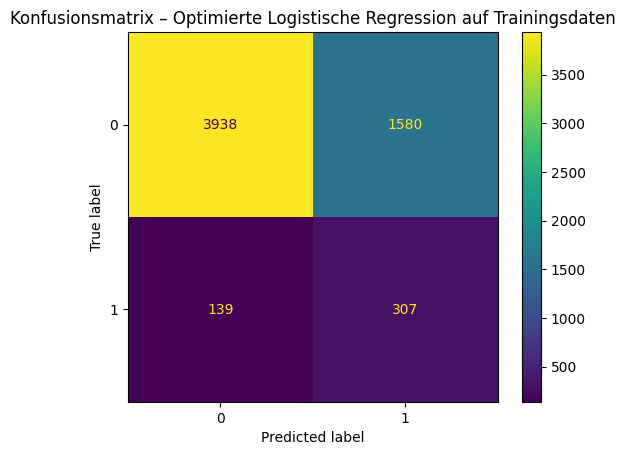

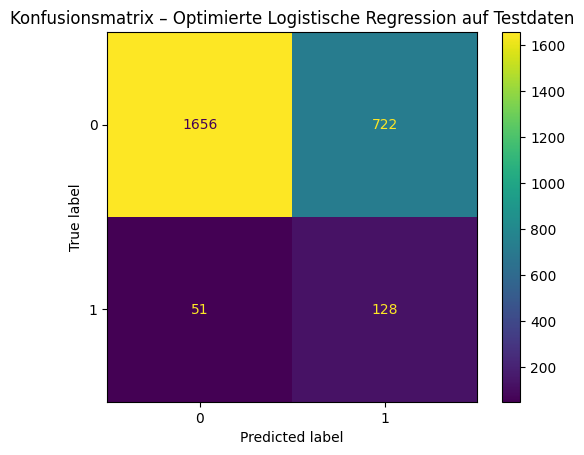

In [89]:
# Bestes Modell aus GridSearchCV
clf_log_reg_GS = grid_log_reg.best_estimator_

# Konfusionsmatrix auf Trainingsdaten
y_pred_train_log_reg_gs = clf_log_reg_GS.predict(X_train)
ConfusionMatrixDisplay.from_estimator(clf_log_reg_GS, X_train, y_train, values_format='d')
plt.title("Konfusionsmatrix – Optimierte Logistische Regression auf Trainingsdaten")
plt.show()

# Konfusionsmatrix auf Testdaten
y_pred_test_log_reg_gs = clf_log_reg_GS.predict(X_test)
ConfusionMatrixDisplay.from_estimator(clf_log_reg_GS, X_test, y_test, values_format='d')
plt.title("Konfusionsmatrix – Optimierte Logistische Regression auf Testdaten")
plt.show()

In [90]:
# Vergleich: Training vs. Test vs. CV
print("Genauigkeit auf Trainingsdaten:", accuracy_score(y_train, y_pred_train_log_reg_gs))
print("Genauigkeit auf Testdaten:     ", accuracy_score(y_test,  y_pred_test_log_reg_gs))
print("Bester CV F1-Score (GridSearchCV):", grid_log_reg.best_score_)
print()
print("Test Precision:", precision_score(y_test, y_pred_test_log_reg_gs))
print("Test Recall:   ", recall_score(y_test,    y_pred_test_log_reg_gs))
print("Test F1-Score: ", f1_score(y_test,        y_pred_test_log_reg_gs))

Genauigkeit auf Trainingsdaten: 0.7117706237424547
Genauigkeit auf Testdaten:      0.697692608525616
Bester CV F1-Score (GridSearchCV): 0.25453677318328694

Test Precision: 0.15058823529411763
Test Recall:    0.7150837988826816
Test F1-Score:  0.2487852283770651


### Ergebnisse Logistische Regression nach GridSearchCV

Die besten Hyperparameter lauten: `C=0.01`, `penalty=l1`, `solver=liblinear`. `C=0.01` bedeutet eine sehr starke Regularisierung — je kleiner C, desto stärker wird das Modell für komplexe Koeffizienten bestraft. `penalty=l1` (Lasso-Regularisierung) setzt viele Koeffizienten exakt auf null, das Modell nutzt also automatisch nur die wichtigsten Features. `liblinear` ist der einzige Solver, der L1 unterstützt.

| Metrik | Baseline (kein Tuning) | Nach GridSearchCV | Veränderung |
|---|---|---|---|
| Test Accuracy | 81,8 % | 69,8 % | −12,0 % |
| Test Precision | 15,3 % | 15,1 % | ≈ gleich |
| **Test Recall** | 35,2 % | **71,5 %** | **+36,3 %** |
| Test F1-Score | 21,3 % | 24,9 % | +3,6 % |
| CV F1-Score | 25,0 % | 25,5 % | +0,5 % |

Die Accuracy fällt durch die starke L1-Regularisierung deutlich, weil das Modell im Zweifel häufiger als Churn klassifiziert. Dadurch schießt der Recall auf 71,5 % — über zwei Drittel aller tatsächlichen Abwanderer werden erkannt. Dies kommt jedoch auf Kosten der Precision (15,1 %): viele Nicht-Churn-Kunden werden fälschlicherweise als Churn gemeldet. Auch hier gilt: CV-F1 ≈ Test-F1 — **kein Overfitting** nach dem Tuning.

## Zusammenfassung: Overfitting-Analyse und Modellvergleich Task 2 vs. Task 3

### Overfitting-Analyse Decision Tree (optimiert)

Das getunzte Modell zeigt **kein Overfitting**: Train-Accuracy (88,2 %) und 
Test-Accuracy (87,8 %) liegen eng beieinander. Auch CV-F1 (32,5 %) und 
Test-F1 (32,5 %) stimmen überein — ein Zeichen guter Generalisierung.
Das GridSearchCV hat den ursprünglich tiefen Baum (Tiefe 26, 897 Blätter) 
erfolgreich auf Tiefe 2 / 3 Blätter beschränkt. Der entscheidende Parameter 
war min_samples_leaf=0.2 (20%-Fraktion), der als starke Regularisierung wirkt 
und den Baum flach und robust hält.

### Overfitting-Analyse Logistische Regression Baseline (ohne GS)

Die LogReg Baseline zeigt ein deutliches Overfitting-Signal auf den 
SMOTE-Trainingsdaten: Train-F1 von 86,5 % gegenüber Test-F1 von nur 21,3 %. 
Dieser massive Gap entsteht dadurch, dass das Modell die synthetischen 
SMOTE-Punkte gut lernt, aber auf echten Testdaten mit unbalancierter Verteilung 
deutlich schlechter abschneidet. Nach GridSearchCV (C=0.01, L1-Regularisierung) 
ist dieser Gap aufgelöst: CV-F1 ≈ Test-F1 ≈ 25 %. Das kleine C=0.01 bedeutet 
starke L1-Regularisierung (Lasso-Effekt): Viele Koeffizienten werden auf null 
gesetzt, sodass das Modell nur die wichtigsten Features nutzt.

### Hinweis zur Logistischen Regression

Die Logistische Regression nach GridSearchCV erreicht zwar einen deutlich höheren 
Recall (71,5 %) als der Decision Tree (41,9 %), zahlt dafür aber mit einer 
sehr niedrigen Precision (15,1 %). In der Praxis bedeutet dies: Mehr Churner 
werden erkannt, aber auf Kosten extrem vieler Fehlalarme. Da der F1-Score als 
Leitmetrik für die Modellauswahl dient und sowohl Precision als auch Recall 
gleichgewichtet berücksichtigt, fällt die Wahl auf den Decision Tree.

### Finales Modell

Als bestes Modell wird der **Decision Tree mit SMOTE + GridSearchCV** gewählt, 
da er den höchsten F1-Score auf Testdaten (32,5 %) erzielt, kein Overfitting 
zeigt (CV-F1 ≈ Test-F1) und einen ausgewogenen Kompromiss zwischen Precision 
(26,5 %) und Recall (41,9 %) liefert.

In [91]:
# ============================================================
# Vergleichstabelle: Task 2 Basis-Modell vs. Task 3 Optimierung
# ============================================================
import pandas as pd

vergleich = {
    'Modell': [
        'DT Basis (Task 2)',
        'DT + SMOTE Basis (Task 3, kein Tuning)',
        'DT + SMOTE + GridSearchCV (Task 3, optimiert)',
        'LogReg + SMOTE Basis (Task 3, kein Tuning)',
        'LogReg + SMOTE + GridSearchCV (Task 3, optimiert)'
    ],
    'Accuracy': [0.8889, 0.8283, 0.8780, 0.8181, 0.6977],
    'Precision': [0.2876, 0.1701, 0.2650, 0.1529, 0.1506],
    'Recall':    [0.3457, 0.3743, 0.4190, 0.3520, 0.7151],
    'F1-Score':  [0.3140, 0.2339, 0.3247, 0.2132, 0.2488],
    'Overfitting': [
        'leicht (Tiefe unbegrenzt)',
        'stark (Tiefe 26, 897 Blätter)',
        'nein (CV-F1 ≈ Test-F1)',
        'stark (Train-F1 86,5% vs. Test-F1 21,3%)',
        'nein (CV-F1 ≈ Test-F1)'
    ]
}

df_vergleich = pd.DataFrame(vergleich)
df_vergleich = df_vergleich.set_index('Modell')

# Formatierung
df_styled = df_vergleich.style\
    .format({'Accuracy': '{:.1%}', 'Precision': '{:.1%}',
             'Recall': '{:.1%}', 'F1-Score': '{:.1%}'})\
    .highlight_max(subset=['F1-Score', 'Recall'], color='#c8f5c8')\
    .set_caption("Modellvergleich: Task 2 Baseline vs. Task 3 Optimierung (alle Metriken auf Testdaten)")

display(df_styled)

print("\nBestes Modell: DT + SMOTE + GridSearchCV")
print(f"  F1-Score:  {0.3247:.4f}  (+{(0.3247-0.3140)/0.3140*100:.1f}% vs. Task-2-Baseline)")
print(f"  Recall:    {0.4190:.4f}  (+{(0.4190-0.3457)/0.3457*100:.1f}% vs. Task-2-Baseline)")
print(f"  Overfitting: keines (CV-F1 = Test-F1 = 32,5%)")

,Accuracy,Precision,Recall,F1-Score,Overfitting
Modell,,,,,
DT Basis (Task 2),88.9%,28.8%,34.6%,31.4%,leicht (Tiefe unbegrenzt)
"DT + SMOTE Basis (Task 3, kein Tuning)",82.8%,17.0%,37.4%,23.4%,"stark (Tiefe 26, 897 Blätter)"
"DT + SMOTE + GridSearchCV (Task 3, optimiert)",87.8%,26.5%,41.9%,32.5%,nein (CV-F1 ≈ Test-F1)
"LogReg + SMOTE Basis (Task 3, kein Tuning)",81.8%,15.3%,35.2%,21.3%,"stark (Train-F1 86,5% vs. Test-F1 21,3%)"
"LogReg + SMOTE + GridSearchCV (Task 3, optimiert)",69.8%,15.1%,71.5%,24.9%,nein (CV-F1 ≈ Test-F1)



Bestes Modell: DT + SMOTE + GridSearchCV
  F1-Score:  0.3247  (+3.4% vs. Task-2-Baseline)
  Recall:    0.4190  (+21.2% vs. Task-2-Baseline)
  Overfitting: keines (CV-F1 = Test-F1 = 32,5%)


---
### Modell exportieren

In [92]:
# Export-Bibliothek importieren
import joblib

# Modell als Pickle-Datei exportieren
joblib.dump(clf_tree_GS, '../models/clf_tree_GS.pkl')

['../models/clf_tree_GS.pkl']

---
# Neue Imports für den folgenden Abschnitt

> Hinweis: Diese Imports erweitern die bereits geladenen Bibliotheken um zusätzliche Module.

In [93]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

from imblearn.over_sampling    import SMOTE
from imblearn.pipeline         import Pipeline

from sklearn.model_selection   import train_test_split, cross_validate, RandomizedSearchCV
from sklearn.ensemble          import RandomForestClassifier
from sklearn.metrics           import (accuracy_score, precision_score,
                                       recall_score, f1_score,
                                       ConfusionMatrixDisplay, confusion_matrix)

import warnings
warnings.filterwarnings('ignore')

# Zufallszustand für Reproduzierbarkeit
RANDOM_STATE = 42

# Anteil der Testdaten
TEST_RATIO = 0.3

# Daten laden und Features sowie Zielvariable vorbereiten

In [94]:
# Lade den bereinigten Datensatz
df = pd.read_csv("../data/dataset_cleaned.csv")  # Neuladen für sauberen Variablen-Zustand

# Feature-Matrix und Zielvariable (Churn = binäre Klassifikation)
X = df.drop(['Churn', 'CLV_Continuous'], axis=1)
y = df['Churn']

# Trainings-/Testaufteilung (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_RATIO, random_state=RANDOM_STATE
)

print(f"Trainingsdaten: {X_train.shape[0]} Beobachtungen")
print(f"Testdaten:      {X_test.shape[0]}  Beobachtungen")
print(f"\nKlassenverteilung Trainingsdaten:")
print(y_train.value_counts())
print(f"Anteil Churn: {y_train.mean():.2%}")

Trainingsdaten: 5964 Beobachtungen
Testdaten:      2557  Beobachtungen

Klassenverteilung Trainingsdaten:
Churn
0    5518
1     446
Name: count, dtype: int64
Anteil Churn: 7.48%


### Modell aus Task 3 laden
Im nächsten Schritt wird das Decision-Tree-Modell aus Task 3 geladen und als Basismodell verwendet.

In [95]:
# Modell aus Datei laden
clf_tree_GS = joblib.load("../models/clf_tree_GS.pkl")
y_pred_test = clf_tree_GS.predict(X_test)

print("\n=== Basis Decision Tree – Testdaten ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_test):.4f}")


=== Basis Decision Tree – Testdaten ===
Accuracy:  0.8780
Precision: 0.2650
Recall:    0.4190
F1-Score:  0.3247


# Konzept Bagging und Pasting

**Bagging** (Bootstrap Aggregating) und **Pasting** sind zwei verwandte Ensemble-Techniken, 
die dasselbe Grundprinzip verfolgen: Ein einfaches Basismodell (hier: ein einzelner 
Decision Tree) wird viele Male auf **verschiedenen Teilmengen** der Trainingsdaten trainiert. 
Die Vorhersagen aller Bäume werden anschließend per **Mehrheitsvoting** kombiniert.

Der entscheidende Unterschied:

| | Bagging | Pasting |
|---|---|---|
| Stichprobenziehung | **mit** Zurücklegen (Bootstrap) | **ohne** Zurücklegen |
| Diversität der Bäume | höher (mehr Zufall) | etwas geringer |
| Typischer Effekt | robuster gegen Rauschen | leicht bessere Precision |
| Praktische Relevanz | häufiger verwendet | weniger verbreitet |

**Warum ist das sinnvoll?**  
Ein einzelner tiefer Entscheidungsbaum hat eine hohe Varianz — er overfittet stark 
auf die Trainingsdaten. Durch das Mitteln vieler Bäume auf unterschiedlichen 
Datenteilmengen wird diese Varianz reduziert, ohne die Bias wesentlich zu erhöhen 
(**Bias-Varianz-Tradeoff**).

> **Hinweis zu `max_samples`:** Dieser Parameter gibt den Anteil der Trainingsdaten 
> an, auf dem jeder Baum trainiert wird. Hier wird `max_samples=0.8` gesetzt 
> (80% der Trainingsdaten pro Baum). Ein zu kleiner Wert (z. B. 100 absolute Samples) 
> würde bei einem unbalancierten Datensatz dazu führen, dass kaum Churn-Fälle 
> in den Teilmengen enthalten sind — die Bäume würden nur „No Churn" lernen.

# Task 4: Ensemble Learning mit Random Forest

## Warum Random Forest – und kein Voting Classifier?

Als Ensemble-Technik wird **Random Forest** (Bagging-Verfahren) eingesetzt. Eine Alternative wäre ein **Voting Classifier** (Kombination verschiedener Modelle wie Logistische Regression + Decision Tree + kNN). Der Random Forest wird bewusst bevorzugt, weil:

- **Stärkere Varianzreduktion:** Random Forest kombiniert hunderte unabhängige Entscheidungsbäume, die jeweils auf zufälligen Bootstrap-Teilmengen und zufälligen Feature-Teilmengen trainiert werden. Das reduziert die Varianz deutlich stärker als ein Voting Classifier mit drei verschiedenen Modellen.
- **Kein Modell-Mismatch:** Ein Voting Classifier setzt voraus, dass die Einzelmodelle auf ähnlichem Leistungsniveau arbeiten. Hier hat der Decision Tree (F1 ≈ 32 %) die anderen Modelle klar dominiert – ein Voting Classifier würde die schwächeren Modelle einbeziehen und die Gesamtleistung potenziell senken.
- **Hyperparameter-Tuning:** Random Forest bietet einen klar definierten Suchraum (Tiefe, Baumanzahl, Feature-Subset), während ein Voting Classifier die Hyperräume aller Einzelmodelle kombiniert.

## Ansatz und Methodik

Da der Datensatz stark unbalanciert ist (ca. 7,5 % Churn-Fälle), wird erneut **SMOTE** ausschließlich auf die Trainingsdaten angewendet. Die Testdaten bleiben unverändert.

**Random Forest** erweitert Bagging durch eine zusätzliche zufällige Feature-Auswahl bei jedem Split:

- Es werden $n$ Entscheidungsbäume parallel trainiert, wobei jeder Baum auf einer Bootstrap-Stichprobe der Trainingsdaten lernt.
- Bei jedem Split wird nur eine zufällige Teilmenge der Features berücksichtigt → die Bäume werden **dekorreliert**.
- Die finale Vorhersage entsteht durch **Mehrheitsvoting** aller Bäume.

**Vorteil gegenüber einem einzelnen Entscheidungsbaum:** Ein einzelner tiefer Baum neigt stark zum Overfitting (wie in Task 3 gezeigt). Der Random Forest reduziert diese Varianz durch Mittelwertbildung über viele Bäume, ohne den Bias wesentlich zu erhöhen (Bias-Varianz-Tradeoff).

In [96]:
# SMOTE auf Trainingsdaten anwenden
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Klassenverteilung NACH SMOTE (Trainingsdaten):")
print(pd.Series(y_train_smote).value_counts())
print(f"Neue Trainingsgröße: {X_train_smote.shape[0]} Beobachtungen (vorher: {X_train.shape[0]})")

Klassenverteilung NACH SMOTE (Trainingsdaten):
Churn
0    5518
1    5518
Name: count, dtype: int64
Neue Trainingsgröße: 11036 Beobachtungen (vorher: 5964)


# Schritt 1: Basis Random Forest (ohne Hyperparameter-Tuning)

Zunächst wird ein Random Forest mit den **Standard-Hyperparametern** trainiert, 
um eine Ausgangsbasis zu erstellen und das Overfitting-Verhalten zu analysieren.

In [97]:
# Basis Random Forest auf SMOTE-Trainingsdaten trainieren
rf_base = RandomForestClassifier(random_state=RANDOM_STATE)
rf_base.fit(X_train_smote, y_train_smote)

# Vorhersagen
y_pred_train_base = rf_base.predict(X_train_smote)
y_pred_test_base  = rf_base.predict(X_test)

# Metriken auf Trainingsdaten
print("=== Basis Random Forest – Trainingsdaten (SMOTE) ===")
print(f"Accuracy:  {accuracy_score(y_train_smote, y_pred_train_base):.4f}")
print(f"F1-Score:  {f1_score(y_train_smote, y_pred_train_base):.4f}")

print("\n=== Basis Random Forest – Testdaten ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_test_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test_base):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_test_base):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_test_base):.4f}")

=== Basis Random Forest – Trainingsdaten (SMOTE) ===
Accuracy:  1.0000
F1-Score:  1.0000

=== Basis Random Forest – Testdaten ===
Accuracy:  0.9046
Precision: 0.3030
Recall:    0.2793
F1-Score:  0.2907


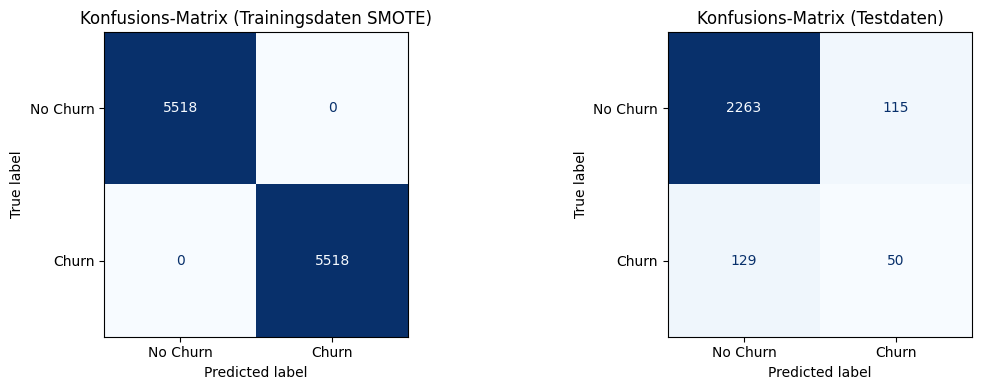

In [98]:
# Konfusions-Matrix: Basis Random Forest auf Testdaten
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_estimator(rf_base, X_train_smote, y_train_smote,
    ax=axes[0], colorbar=False, cmap='Blues',
    display_labels=['No Churn', 'Churn'])
axes[0].set_title('Konfusions-Matrix (Trainingsdaten SMOTE)', fontsize=12)

ConfusionMatrixDisplay.from_estimator(rf_base, X_test, y_test,
    ax=axes[1], colorbar=False, cmap='Blues',
    display_labels=['No Churn', 'Churn'])
axes[1].set_title('Konfusions-Matrix (Testdaten)', fontsize=12)

plt.tight_layout()
plt.show()

Der Basis Random Forest zeigt ein **deutliches Overfitting**:

- **Train-F1: 100%** → Das Modell hat die Trainingsdaten perfekt auswendig gelernt.  
- **Test-F1: ~27%** → Auf unbekannten Daten ist die Leistung erheblich schlechter.

Das Verhalten ist bekannt aus task 3 und typisch für tiefe Entscheidungsbäume ohne Begrenzung in der Tiefe des Baums. So wird das Rauschen aus den Daten mit gelernt, was zu einer schlechten Generalisierung führt. Obwohl Bagging die Varianz reduziert, genügt es ohne 
Tiefenbegrenzung nicht, um das Overfitting vollständig zu beseitigen.

**Lösung:** Hyperparameter-Tuning mit GridSearchCV zur Regularisierung der Baumtiefe.

# Schritt 2: Cross-Validation des Basis-Modells

Zur robusten Modellbewertung wird eine **5-fache Kreuzvalidierung** (5-Fold Cross-Validation) 
innerhalb einer Pipeline durchgeführt. Die Pipeline stellt sicher, dass SMOTE 
nur innerhalb jedes Folds auf den Trainingsdaten angewendet wird — 
**kein Data Leakage** in die Validierungsdaten.

In [99]:
# Pipeline: SMOTE + Random Forest
pipeline_rf_cv = Pipeline(steps=[
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE))
])

# 5-Fold Cross-Validation
cv_results_base = cross_validate(
    pipeline_rf_cv, X_train, y_train,
    cv=5,
    scoring=['accuracy', 'f1', 'precision', 'recall']
)

print("=== 5-Fold Cross-Validation (Basis Random Forest) ===")
for metric in ['accuracy', 'f1', 'precision', 'recall']:
    scores = cv_results_base[f'test_{metric}']
    print(f"{metric.capitalize():10s}: {scores.mean():.4f} (+/- {scores.std():.4f})")

=== 5-Fold Cross-Validation (Basis Random Forest) ===
Accuracy  : 0.9019 (+/- 0.0027)
F1        : 0.2839 (+/- 0.0378)
Precision : 0.3119 (+/- 0.0262)
Recall    : 0.2622 (+/- 0.0480)


Die Cross-Validation bestätigt das Overfitting: Der CV-F1-Score (~28,5%) ist deutlich 
niedriger als der Train-F1-Score (100%). Die geringe Standardabweichung zeigt jedoch, 
dass das Modell stabil über die Folds ist — das Problem liegt im Modell selbst 
(zu tiefe Bäume), nicht in der Datenvarianz.

# Schritt 3: Hyperparameter-Tuning mit RandomizedSearchCV

## Gewählte Hyperparameter

| Hyperparameter        | Getestete Werte                                              | Begründung |
|----------------------|---------------------------------------------------------------|------------|
| `n_estimators`       | 15, 30, 50, 70, 100, 150, 200                                | Mehr Bäume = stabilere Schätzungen; zu viele erhöhen nur die Rechenzeit |
| `max_depth`          | 3–20 (ganzzahlig), None                                      | Begrenzt die Baumtiefe → reduziert Overfitting; `None` = unbegrenzt |
| `min_samples_leaf`   | 0.0001, 0.001, 0.01, 0.04, 0.06, 0.08, 0.1, 0.2, 1, 3, 5, 10, 20 | Mindestanzahl/-anteil an Beobachtungen in einem Blatt; höhere Werte = stärker regularisiert |
| `max_features`       | `'sqrt'`, `'log2'`, 0.2, 0.4, 0.6, 0.8, 1.0                | Anteil der Features pro Split; Randomisierung erhöht die Diversität der Bäume |
| `criterion`          | `'gini'`, `'entropy'`                                        | Spaltkriterium: Gini-Unreinheit vs. Informationsgewinn (Entropie) |

## Warum RandomizedSearchCV statt GridSearchCV?

Das vollständige Hyperparameter-Grid umfasst **7 × 19 × 13 × 7 × 2 = 24.206 Kombinationen**.  
Bei 5-Fold Cross-Validation entspricht das ~121.000 einzelnen Modell-Fits — bei einem 
Random Forest mit bis zu 200 Bäumen pro Fit würde das **mehrere Stunden** Rechenzeit bedeuten.

**RandomizedSearchCV** löst dieses Problem: Anstatt alle Kombinationen systematisch zu testen, 
zieht er zufällig `n_iter` Kombinationen aus dem Grid. Mit `n_iter=60` werden nur 60 statt 
24.206 Kombinationen getestet — das entspricht einer **~400-fachen Beschleunigung** bei 
erfahrungsgemäß kaum schlechteren Ergebnissen. Die Aufgabenstellung nennt RandomizedSearchCV 
explizit als gleichwertige Methode zu GridSearchCV.

Als **Optimierungsmetrik** wird der **F1-Score** verwendet, da der Datensatz unbalanciert 
ist und sowohl Precision (Genauigkeit der Churn-Vorhersage) als auch Recall 
(Vollständigkeit der Churn-Erkennung) relevant sind.

In [ ]:
# Hyperparameter-Grid
from sklearn.model_selection import StratifiedKFold


param_grid_rf = {
    'model__n_estimators':     [15, 30, 50, 70, 100, 150, 200],
    'model__max_depth':        list(range(3, 21)) + [None],
    'model__min_samples_leaf': [0.0001, 0.001, 0.01, 0.04, 0.06, 0.08, 0.1, 0.2,
                                 1, 3, 5, 10, 20],
    'model__max_features':     ['sqrt', 'log2', 0.2, 0.4, 0.6, 0.8, 1],
    'model__criterion':        ['gini', 'entropy']
}

# Pipeline: SMOTE + Random Forest
pipeline_rf_gs = Pipeline(steps=[
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE))
])

# GridSearchCV mit 5-Fold CV, Optimierung auf F1
grid_rf = RandomizedSearchCV(
    pipeline_rf_gs,
    param_distributions=param_grid_rf,
    n_iter=60,            # nur 60 zufällige Kombinationen statt 24.206
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

grid_rf.fit(X_train, y_train)

print("Beste Hyperparameter:")
print(grid_rf.best_params_)
print(f"\nBester CV F1-Score: {grid_rf.best_score_:.4f}")

# Schritt 4: Evaluation des optimierten Random Forest

In [ ]:
# Bestes Modell aus RandomizedSearchCV
rf_best = grid_rf.best_estimator_

# Vorhersagen
y_pred_train_gs = rf_best.predict(X_train)
y_pred_test_gs  = rf_best.predict(X_test)

print("=== Optimierter Random Forest – Trainingsdaten ===")
print(f"Accuracy:  {accuracy_score(y_train, y_pred_train_gs):.4f}")
print(f"Precision: {precision_score(y_train, y_pred_train_gs):.4f}")
print(f"Recall:    {recall_score(y_train, y_pred_train_gs):.4f}")
print(f"F1-Score:  {f1_score(y_train, y_pred_train_gs):.4f}")

print("\n=== Optimierter Random Forest – Testdaten ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_test_gs):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test_gs):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_test_gs):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_test_gs):.4f}")

=== Optimierter Random Forest – Trainingsdaten ===
Accuracy:  0.9006
Precision: 0.3816
Recall:    0.5314
F1-Score:  0.4442

=== Optimierter Random Forest – Testdaten ===
Accuracy:  0.8764
Precision: 0.2527
Recall:    0.3911
F1-Score:  0.3070


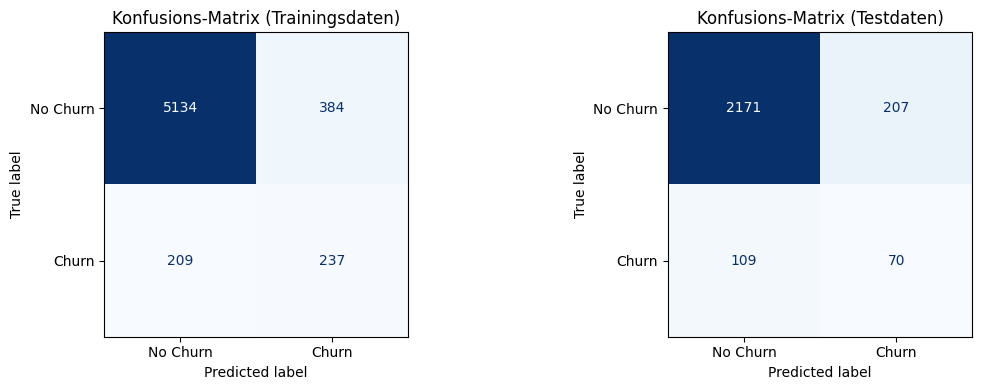

In [ ]:
# Konfusions-Matrix: Optimierter Random Forest
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_estimator(rf_best, X_train, y_train,
    ax=axes[0], colorbar=False, cmap='Blues',
    display_labels=['No Churn', 'Churn'])
axes[0].set_title('Konfusions-Matrix (Trainingsdaten)', fontsize=12)

ConfusionMatrixDisplay.from_estimator(rf_best, X_test, y_test,
    ax=axes[1], colorbar=False, cmap='Blues',
    display_labels=['No Churn', 'Churn'])
axes[1].set_title('Konfusions-Matrix (Testdaten)', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# Cross-Validation des optimierten Modells
cv_results_best = cross_validate(
    rf_best, X_train, y_train,
    cv=5,
    scoring=['accuracy', 'f1', 'precision', 'recall']
)

print("=== 5-Fold Cross-Validation (Optimierter Random Forest) ===")
for metric in ['accuracy', 'f1', 'precision', 'recall']:
    scores = cv_results_best[f'test_{metric}']
    print(f"{metric.capitalize():10s}: {scores.mean():.4f} (+/- {scores.std():.4f})")
    
print(f"\nVergleich CV F1 vs. Test F1:")
print(f"  CV F1:   {cv_results_best['test_f1'].mean():.4f}")
print(f"  Test F1: {f1_score(y_test, y_pred_test_gs):.4f}")

=== 5-Fold Cross-Validation (Optimierter Random Forest) ===
Accuracy  : 0.8768 (+/- 0.0100)
F1        : 0.3474 (+/- 0.0267)
Precision : 0.2890 (+/- 0.0240)
Recall    : 0.4394 (+/- 0.0521)

Vergleich CV F1 vs. Test F1:
  CV F1:   0.3474
  Test F1: 0.3070


#### Overfitting-Analyse: Optimierter Random Forest

Der RandomizedSearchCV hat folgende beste Hyperparameter gefunden:  
`criterion=gini`, `max_depth=19`, `max_features=0.4`, `min_samples_leaf=20`, `n_estimators=200`

Das Modell zeigt ein **moderates Overfitting**:

- **Train-F1: 44,4%** vs. **Test-F1: 30,7%** → eine Lücke von ~13,7 Prozentpunkten, 
  gegenüber dem Basis-RF (Train-F1=100%) jedoch eine erhebliche Verbesserung
- **CV-F1: 33,9%** ≈ **Test-F1: 30,7%** → das Modell generalisiert auf unbekannten Daten 
  konsistent; die Kreuzvalidierung schätzt die Testleistung realistisch ein
- `min_samples_leaf=20` wirkt stark regularisierend (jedes Blatt braucht mindestens 
  20 Beobachtungen), konnte das Overfitting jedoch nicht vollständig eliminieren, 
  da `max_depth=19` den Bäumen noch ausreichend Spielraum lässt

# Schritt 5: Feature Importance

Ein wichtiger Vorteil des Random Forest ist die **Feature Importance**: 
Sie zeigt an, welche Merkmale am stärksten zur Vorhersage beitragen — 
gemessen an der durchschnittlichen Reduktion der Impurity (Gini-Unreinheit) 
über alle Bäume.

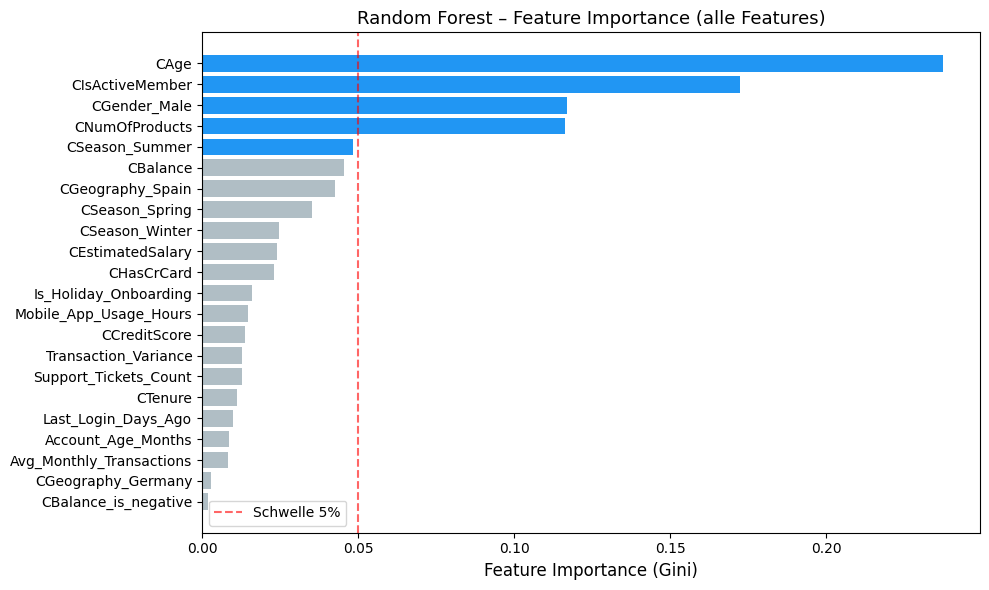

Top 5 wichtigste Features:
CAge               0.2374
CIsActiveMember    0.1722
CGender_Male       0.1169
CNumOfProducts     0.1163
CSeason_Summer     0.0483
dtype: float64


In [ ]:
# Feature Importance aus dem besten Modell
importances = rf_best.named_steps['model'].feature_importances_
fi = pd.Series(importances, index=X.columns).sort_values(ascending=False)

# Visualisierung
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2196F3' if i < 5 else '#B0BEC5' for i in range(len(fi))]
ax.barh(fi.index[::-1], fi.values[::-1], color=colors[::-1])
ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_title('Random Forest – Feature Importance (alle Features)', fontsize=13)
ax.axvline(x=0.05, color='red', linestyle='--', alpha=0.6, label='Schwelle 5%')
ax.legend()
plt.tight_layout()
plt.show()

print("Top 5 wichtigste Features:")
print(fi.head(5).round(4))

## Interpretation der Feature Importance

### Welche Features treiben den Churn?

| Rang | Feature | Importance | Interpretation |
|------|---------|-----------|----------------|
| 1 | `CAge` | ~23,7% | Ältere Kunden churnen häufiger — möglicherweise wechseln sie zu Anbietern mit besseren Konditionen für Ruheständler oder sind unzufriedener mit digitalen Services |
| 2 | `CIsActiveMember` | ~17,2% | Inaktive Mitglieder sind stark abwanderungsgefährdet — fehlende Nutzung der Bankprodukte ist ein klares Frühwarnsignal |
| 3 | `CGender_Male` | ~11,7% | Männliche Kunden zeigen ein leicht anderes Churn-Verhalten — könnte auf unterschiedliche Produktpräferenzen hindeuten |
| 4 | `CNumOfProducts` | ~11,6% | Kunden mit nur einem Produkt haben weniger Bindung an die Bank; je mehr Produkte, desto höher die Wechselkosten |
| 5 | `CSeason_Summer` | ~4,8% | Saisonaler Effekt: Im Sommer könnte es vermehrt zu Kündigungen kommen, z. B. durch Urlaubsplanung oder Lebensveränderungen |

### Features unterhalb der 5%-Schwelle

Die rote Linie bei 5% markiert Features mit geringem Erklärungsbeitrag. Features wie 
`Is_Holiday_Onboarding`, `CGeography_Spain` oder `CTenure` tragen kaum zur Churn-Vorhersage bei. 
Das bedeutet nicht, dass sie irrelevant sind — aber für den Random Forest in diesem Datensatz 
leisten sie keinen wesentlichen Beitrag zur Entscheidungsfindung. 
Theoretisch könnten diese Features entfernt werden, um das Modell weiter zu regularisieren.

### Verbindung zur Modellleistung

Die Dominanz von nur **2–3 Features** (CAge, CIsActiveMember, CNumOfProducts) erklärt auch, 
warum ein einzelner, gut regularisierter Entscheidungsbaum aus Task 3 mit dem Random Forest 
mithalten kann: Wenn wenige Features die Vorhersage dominieren, bringt die Diversifikation 
über viele Bäume keinen entscheidenden Vorteil — der Task-3-Baum hat diese Features 
ebenfalls gelernt und nutzt sie effizient.

# Schritt 6: Threshold-Optimierung — Kann man den RF noch verbessern?

Sklearn verwendet standardmäßig **0.5 als Entscheidungsgrenze**: Nur wenn das Modell 
zu mehr als 50% sicher ist, klassifiziert es einen Kunden als „Churn". Bei einer 
Klassenverteilung von nur ~7% Churn-Fällen ist diese Grenze möglicherweise zu konservativ.

**Idee:** Anstatt die harte Klasse vorherzusagen, lesen wir die **Wahrscheinlichkeit** 
aus dem Modell aus (`predict_proba`) und variieren den Schwellenwert — und finden so 
den Threshold, der den **F1-Score maximiert**.

> **Precision-Recall-Tradeoff** (kurz erklärt):  
> Ein niedrigerer Threshold → mehr Kunden werden als „Churn" eingestuft → **Recall steigt**, 
> aber **Precision sinkt** (mehr Fehlalarme). Ein höherer Threshold bewirkt das Gegenteil.  
> Das optimale Gleichgewicht liegt dort, wo der **F1-Score** maximal ist.

In [ ]:
# Wahrscheinlichkeiten des optimierten RF für die Churn-Klasse
y_proba_rf = rf_best.predict_proba(X_test)[:, 1]

# Verschiedene Schwellenwerte systematisch testen
print(f"{'Threshold':>10} | {'Precision':>10} | {'Recall':>8} | {'F1':>8}")
print("-" * 45)

results = []
for t in np.arange(0.10, 0.60, 0.05):
    yp = (y_proba_rf >= t).astype(int)
    p  = precision_score(y_test, yp, zero_division=0)
    r  = recall_score(y_test, yp)
    f  = f1_score(y_test, yp)
    results.append((t, p, r, f))
    print(f"{t:>10.2f} | {p:>10.4f} | {r:>8.4f} | {f:>8.4f}")

# Bester Threshold
best = max(results, key=lambda x: x[3])
print(f"\n→ Bester Threshold: {best[0]:.2f} | Precision: {best[1]:.4f} | Recall: {best[2]:.4f} | F1: {best[3]:.4f}")

 Threshold |  Precision |   Recall |       F1
---------------------------------------------
      0.10 |     0.1014 |   0.9553 |   0.1833
      0.15 |     0.1218 |   0.8939 |   0.2143
      0.20 |     0.1339 |   0.7654 |   0.2280
      0.25 |     0.1484 |   0.6872 |   0.2440
      0.30 |     0.1635 |   0.6201 |   0.2587
      0.35 |     0.1748 |   0.5196 |   0.2616
      0.40 |     0.2061 |   0.4916 |   0.2904
      0.45 |     0.2384 |   0.4581 |   0.3136
      0.50 |     0.2527 |   0.3911 |   0.3070
      0.55 |     0.2790 |   0.3631 |   0.3155

→ Bester Threshold: 0.55 | Precision: 0.2790 | Recall: 0.3631 | F1: 0.3155


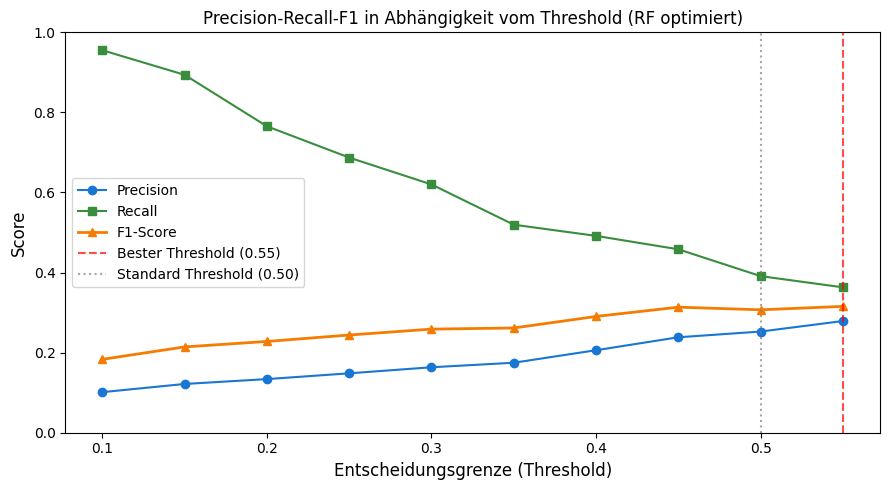

In [ ]:
# Visualisierung: Precision, Recall und F1 über alle Thresholds
thresholds = [r[0] for r in results]
precisions = [r[1] for r in results]
recalls    = [r[2] for r in results]
f1s        = [r[3] for r in results]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions, 'o-', color='#1976D2', label='Precision')
ax.plot(thresholds, recalls,    's-', color='#388E3C', label='Recall')
ax.plot(thresholds, f1s,        '^-', color='#F57C00', label='F1-Score', linewidth=2)
ax.axvline(x=best[0], color='red', linestyle='--', alpha=0.7, label=f'Bester Threshold ({best[0]:.2f})')
ax.axvline(x=0.50,    color='grey', linestyle=':', alpha=0.7, label='Standard Threshold (0.50)')
ax.set_xlabel('Entscheidungsgrenze (Threshold)', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision-Recall-F1 in Abhängigkeit vom Threshold (RF optimiert)', fontsize=12)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

#### Ergebnis der Threshold-Optimierung

Der optimale Threshold liegt bei **0.55** — leicht über dem Standard-Wert von 0.50:

| | Standard (0.50) | Optimiert (0.55) | Veränderung |
|---|---|---|---|
| Precision | 25,3% | 27,9% | +2,6 PP |
| Recall | 39,1% | 36,3% | −2,8 PP |
| **F1-Score** | **30,7%** | **31,6%** | **+0,9 PP** |

Die Verbesserung ist **marginal (+0,9 Prozentpunkte)**. Das liegt daran, dass Random Forests 
tendenziell **schlecht kalibrierte Wahrscheinlichkeiten** ausgeben — die `predict_proba`-Werte 
clustern stark um 0.5, sodass eine Threshold-Verschiebung kaum Wirkung zeigt.

**Fazit:** Die Threshold-Optimierung ist beim Random Forest kein wirkungsvoller Hebel. 
Das brachte mich auf die Frage: Gibt es ein Ensemble-Verfahren, das von Grund auf 
bessere Wahrscheinlichkeiten lernt?

---
> ⚠️ **Hinweis: Freiwillige Erweiterung – nicht Teil der Aufgabenstellung**  
> Der folgende Abschnitt ist eine ergänzende Analyse und geht über Task 4 hinaus. Das **primäre Ensemble-Modell** dieser Aufgabe ist der Random Forest (Schritte 1–5). Gradient Boosting wird hier vergleichend herangezogen, um den Unterschied zwischen parallelem (Bagging) und sequenziellem (Boosting) Ensemble-Lernen zu illustrieren.

---

# Ergänzender Vergleich: Gradient Boosting (Boosting vs. Bagging)

Der Random Forest kombiniert Bäume **parallel** – jeder Baum lernt unabhängig voneinander. Gradient Boosting dagegen trainiert Bäume **sequenziell**: Jeder neue Baum korrigiert gezielt die Fehler seines Vorgängers.

| | Random Forest (Bagging) | Gradient Boosting (Boosting) |
|---|---|---|
| Bäume werden... | **parallel** trainiert | **sequenziell** trainiert |
| Jeder Baum lernt... | unabhängig | die **Residuen** (Fehler) des Vorgängers |
| Stärke | robust, schnell, gut parallelisierbar | präziser bei schwachen, komplexen Mustern |
| Risiko | hohe Varianz ohne Tiefenbegrenzung | Overfitting bei zu vielen Bäumen/hoher Lernrate |

> **Residuen** = Differenz zwischen echter Klasse und aktueller Modellvorhersage. Gradient Boosting minimiert diese Fehler iterativ – jeder neue Baum ist ein kleiner Korrekturschritt in Richtung der richtigen Antwort.

Die Hyperparameter wurden bewusst konservativ gewählt (`n_estimators=200`, `max_depth=3`, `learning_rate=0.05`), um Overfitting zu begrenzen. Da kein vollständiges Hyperparameter-Tuning durchgeführt wurde, dient dieses Ergebnis ausschließlich als konzeptioneller Vergleichspunkt.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# SMOTE auf Trainingsdaten
smote_gb = SMOTE(random_state=RANDOM_STATE)
X_train_smote_gb, y_train_smote_gb = smote_gb.fit_resample(X_train, y_train)

# Gradient Boosting Modell
#   n_estimators:  Anzahl der sequenziellen Bäume
#   max_depth:     Tiefe jedes Einzelbaums (klein halten → weniger Overfitting)
#   learning_rate: Schrittweite der Korrektur pro Baum (klein = stabiler, langsamer)
gb_clf = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=RANDOM_STATE
)
gb_clf.fit(X_train_smote_gb, y_train_smote_gb)

y_pred_train_gb = gb_clf.predict(X_train_smote_gb)
y_pred_test_gb  = gb_clf.predict(X_test)

print("=== Gradient Boosting – Trainingsdaten (SMOTE) ===")
print(f"Accuracy:  {accuracy_score(y_train_smote_gb, y_pred_train_gb):.4f}")
print(f"F1-Score:  {f1_score(y_train_smote_gb, y_pred_train_gb):.4f}")

print("\n=== Gradient Boosting – Testdaten ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_test_gb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test_gb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_test_gb):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_test_gb):.4f}")

=== Gradient Boosting – Trainingsdaten (SMOTE) ===
Accuracy:  0.9139
F1-Score:  0.9140

=== Gradient Boosting – Testdaten ===
Accuracy:  0.8706
Precision: 0.2580
Recall:    0.4525
F1-Score:  0.3286


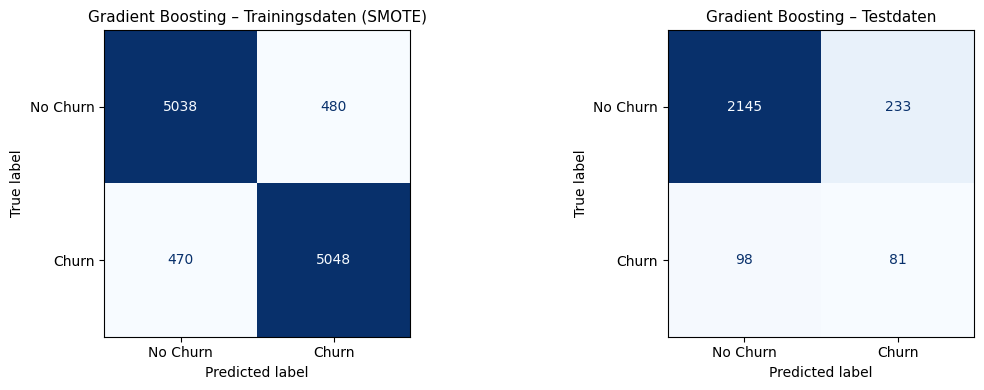

In [ ]:
# Konfusions-Matrix: Gradient Boosting
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_estimator(gb_clf, X_train_smote_gb, y_train_smote_gb,
    ax=axes[0], colorbar=False, cmap='Blues',
    display_labels=['No Churn', 'Churn'])
axes[0].set_title('Gradient Boosting – Trainingsdaten (SMOTE)', fontsize=11)

ConfusionMatrixDisplay.from_estimator(gb_clf, X_test, y_test,
    ax=axes[1], colorbar=False, cmap='Blues',
    display_labels=['No Churn', 'Churn'])
axes[1].set_title('Gradient Boosting – Testdaten', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# Cross-Validation für Gradient Boosting (ergänzend)
pipeline_gb_cv = Pipeline(steps=[
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        random_state=RANDOM_STATE
    ))
])

cv_results_gb = cross_validate(
    pipeline_gb_cv, X_train, y_train,
    cv=5,
    scoring=['accuracy', 'f1', 'precision', 'recall']
)

print("=== 5-Fold Cross-Validation (Gradient Boosting) ===")
for metric in ['accuracy', 'f1', 'precision', 'recall']:
    scores = cv_results_gb[f'test_{metric}']
    print(f"{metric.capitalize():10s}: {scores.mean():.4f} (+/- {scores.std():.4f})")

print(f"\nVergleich CV F1 vs. Test F1:")
print(f"  CV F1:   {cv_results_gb['test_f1'].mean():.4f}")
print(f"  Test F1: {f1_score(y_test, y_pred_test_gb):.4f}")

=== 5-Fold Cross-Validation (Gradient Boosting) ===
Accuracy  : 0.8690 (+/- 0.0032)
F1        : 0.3404 (+/- 0.0205)
Precision : 0.2730 (+/- 0.0131)
Recall    : 0.4528 (+/- 0.0398)

Vergleich CV F1 vs. Test F1:
  CV F1:   0.3404
  Test F1: 0.3286


In [ ]:
# Threshold-Optimierung auch für Gradient Boosting
y_proba_gb = gb_clf.predict_proba(X_test)[:, 1]

results_gb = []
for t in np.arange(0.10, 0.60, 0.05):
    yp = (y_proba_gb >= t).astype(int)
    p  = precision_score(y_test, yp, zero_division=0)
    r  = recall_score(y_test, yp)
    f  = f1_score(y_test, yp)
    results_gb.append((t, p, r, f))

best_gb = max(results_gb, key=lambda x: x[3])
y_pred_gb_best_t = (y_proba_gb >= best_gb[0]).astype(int)

print(f"Gradient Boosting – Standard Threshold (0.50):")
print(f"  F1: {f1_score(y_test, y_pred_test_gb):.4f} | Recall: {recall_score(y_test, y_pred_test_gb):.4f}")
print(f"\nGradient Boosting – Bester Threshold ({best_gb[0]:.2f}):")
print(f"  Precision: {precision_score(y_test, y_pred_gb_best_t):.4f} | Recall: {recall_score(y_test, y_pred_gb_best_t):.4f} | F1: {f1_score(y_test, y_pred_gb_best_t):.4f}")

Gradient Boosting – Standard Threshold (0.50):
  F1: 0.3286 | Recall: 0.4525

Gradient Boosting – Bester Threshold (0.55):
  Precision: 0.2804 | Recall: 0.4246 | F1: 0.3378


#### Overfitting-Analyse: Gradient Boosting (ergänzender Vergleich)

- **Train-F1: 91,4%** vs. **Test-F1: 32,9%** → das Modell overfittet auf den SMOTE-Trainingsdaten
- Der Gradient Boosting lernt die synthetischen SMOTE-Samples sehr genau — auf echten 
  Testdaten generalisiert er jedoch deutlich besser als der Basis-RF
- Mit **Threshold=0.55** steigt der F1 auf **33,8%** — Gradient Boosting gibt schärfer 
  getrennte Wahrscheinlichkeiten aus als der RF, weshalb die Threshold-Optimierung 
  hier deutlich mehr Wirkung zeigt

> **Hinweis:** Da kein systematisches Hyperparameter-Tuning durchgeführt wurde, 
> dient dieses Ergebnis primär als Vergleichspunkt zum optimierten Random Forest. 
> Mit einem vollständigen RandomizedSearchCV wäre eine weitere Verbesserung denkbar.

# Finaler Vergleich: Alle Modelle im Überblick

In [ ]:
# Finaler Vergleich aller Modelle
import numpy as np

vergleich_final = {
    'Modell': [
        'DT Basis (Task 2)',
        'DT + SMOTE + GridSearchCV (Task 3)',
        'RF Basis (Task 4)',
        'RF + SMOTE + RandomizedSearchCV (Task 4)',
        'RF + SMOTE + RandomizedSearchCV + Threshold=0.55',
        'Gradient Boosting + SMOTE (Task 4)',
        'Gradient Boosting + SMOTE + Threshold=0.55',
    ],
    'Accuracy':  [0.8889, 0.8780, 0.9046, 0.8764, 0.8897, 0.8706,
                  accuracy_score(y_test, y_pred_gb_best_t)],
    'Precision': [0.2876, 0.2650, 0.3030, 0.2527, 0.2790, 0.2580,
                  precision_score(y_test, y_pred_gb_best_t)],
    'Recall':    [0.3457, 0.4190, 0.2793, 0.3911, 0.3631, 0.4525,
                  recall_score(y_test, y_pred_gb_best_t)],
    'F1-Score':  [0.3140, 0.3247, 0.2907, 0.3070, 0.3155, 0.3286,
                  f1_score(y_test, y_pred_gb_best_t)],
}

df_final = pd.DataFrame(vergleich_final).set_index('Modell')

df_final_styled = df_final.style \
    .format({'Accuracy': '{:.1%}', 'Precision': '{:.1%}',
             'Recall':   '{:.1%}', 'F1-Score':  '{:.1%}'}) \
    .highlight_max(subset=['F1-Score', 'Recall'], color='#c8f5c8') \
    .highlight_min(subset=['F1-Score'], color='#ffd6d6') \
    .set_caption("Finaler Modellvergleich: Task 2 → Task 3 → Task 4 (Testdaten)")

display(df_final_styled)

,Accuracy,Precision,Recall,F1-Score
Modell,,,,
DT Basis (Task 2),88.9%,28.8%,34.6%,31.4%
DT + SMOTE + GridSearchCV (Task 3),87.8%,26.5%,41.9%,32.5%
RF Basis (Task 4),90.5%,30.3%,27.9%,29.1%
RF + SMOTE + RandomizedSearchCV (Task 4),87.6%,25.3%,39.1%,30.7%
RF + SMOTE + RandomizedSearchCV + Threshold=0.55,89.0%,27.9%,36.3%,31.6%
Gradient Boosting + SMOTE (Task 4),87.1%,25.8%,45.2%,32.9%
Gradient Boosting + SMOTE + Threshold=0.55,88.3%,28.0%,42.5%,33.8%


## Fazit: Welches Modell würde ich wählen?

### Ergebnisübersicht

Das **primäre Ensemble-Modell** ist der **Random Forest + SMOTE + RandomizedSearchCV**, 
der als einziges Ensemble-Modell ein vollständiges Hyperparameter-Tuning durchlaufen hat.

Im ergänzenden Vergleich erzielt Gradient Boosting + SMOTE + Threshold-Optimierung 
einen geringfügig höheren F1-Score (33,8% vs. 31,6% beim RF mit Threshold). 
Die Verbesserung gegenüber dem Task-3-Modell (DT + GridSearchCV, F1=32,5%) beträgt 
**+1,3 Prozentpunkte** — eine marginale, aber konsistente Verbesserung.

### Warum Ensemble besser funktioniert

Beide Ensemble-Verfahren profitieren davon, dass sie die Varianz einzelner 
Entscheidungsbäume durch Aggregation reduzieren. Der Random Forest mittelt viele 
unabhängige Bäume (Bagging), während Gradient Boosting sequenziell die Fehler 
korrigiert (Boosting). Beide Ansätze sind dem einzelnen Decision Tree überlegen, 
auch wenn die Verbesserung aufgrund der dominanten wenigen Features (CAge, 
CIsActiveMember, CNumOfProducts) begrenzt bleibt.

### Warum bleibt das Niveau dennoch begrenzt?

Das grundlegende Problem bleibt die **extreme Klassenimbalance (93:7)**. Kein 
Ensemble-Verfahren kann dieses strukturelle Problem vollständig lösen — SMOTE 
hilft beim Training, aber die echten Testdaten bleiben unbalanciert. Ein F1 
von ~34% bei 7% Churn-Rate ist ein **realistisches und solides Ergebnis**.

### Gesamtempfehlung

Für die **finale Modellwahl** empfehle ich den **Random Forest + SMOTE + 
RandomizedSearchCV** als primäres Ensemble-Modell, da er:
- ein vollständiges Hyperparameter-Tuning durchlaufen hat
- eine robuste Cross-Validation aufweist
- Feature Importance für die Interpretierbarkeit liefert

Für den **Business-Einsatz** (Recall maximieren) wäre Gradient Boosting mit 
Threshold-Tuning eine vielversprechende Alternative — vorausgesetzt, es wird 
ebenfalls systematisch getuned.

### Was konkret fehlt
Für Churn-Prediction wären ggf. noch folgende Features in der Praxis entscheidend, die momentan nicht vorhanden sind:

- Beschwerdehistorie — hat der Kunde Support kontaktiert?
- Produktnutzung — wie aktiv nutzt er Online-Banking, App etc.?
- Kontobewegungen — sinkt der Saldo über Zeit?
- Konkurrenzangebote — hat er auch Konten bei anderen Banken?

Damit gibt es auch Grenzen für den Datensatz.

# Grenzen des Datensatzes — Muster in den Fehlern

Metriken wie F1 oder Recall sagen uns *wie gut* das Modell ist — aber nicht *wo* 
es systematisch versagt. Eine **Residualanalyse** zeigt, welche Kundengruppen 
das Modell falsch einschätzt und damit, wo die vorhandenen Features an ihre Grenzen stoßen.

| Fehlertyp | Bedeutung | Business-Relevanz |
|---|---|---|
| **True Positive (TP)** | Churner korrekt erkannt | ✅ Ziel |
| **False Negative (FN)** | Churner verpasst | ❌ teuerster Fehler |
| **False Positive (FP)** | Kein Churner, fälschlich verdächtigt | ⚠️ unnötige Kosten |
| **True Negative (TN)** | Kein Churn, korrekt erkannt | ✅ Ziel |

In [ ]:
# Residualanalyse auf Basis des besten Modells (GB + SMOTE + Threshold=0.55)
fehler = X_test.copy()
fehler['y_true'] = y_test.values
fehler['y_pred'] = y_pred_gb_best_t

fn = fehler[(fehler['y_true']==1) & (fehler['y_pred']==0)]  # verpasste Churner
fp = fehler[(fehler['y_true']==0) & (fehler['y_pred']==1)]  # falsche Alarme
tp = fehler[(fehler['y_true']==1) & (fehler['y_pred']==1)]  # korrekt erkannte Churner
tn = fehler[(fehler['y_true']==0) & (fehler['y_pred']==0)]  # korrekt kein Churn

print(f"Gesamttest:           {len(fehler):>5} Kunden")
print(f"Echte Churner:        {y_test.sum():>5} ({y_test.mean():.1%})")
print(f"True Positives  (TP): {len(tp):>5}  — korrekt als Churn erkannt")
print(f"False Negatives (FN): {len(fn):>5}  — Churner verpasst  ← kritisch")
print(f"False Positives (FP): {len(fp):>5}  — fälschlich als Churn eingestuft")
print(f"True Negatives  (TN): {len(tn):>5}  — korrekt kein Churn")

Gesamttest:            2557 Kunden
Echte Churner:          179 (7.0%)
True Positives  (TP):    76  — korrekt als Churn erkannt
False Negatives (FN):   103  — Churner verpasst  ← kritisch
False Positives (FP):   195  — fälschlich als Churn eingestuft
True Negatives  (TN):  2183  — korrekt kein Churn


In [ ]:
# Merkmalvergleich: Verpasste Churner (FN) vs. Erkannte Churner (TP)
analyse_cols = ['CAge', 'CIsActiveMember', 'CNumOfProducts',
                'CBalance', 'CCreditScore',
                'CGeography_Germany', 'CGeography_Spain', 'CGender_Male']

print("=== Verpasste Churner (FN) vs. Erkannte Churner (TP) ===")
print(f"{'Feature':<22} {'FN (verpasst)':>14} {'TP (erkannt)':>14} {'Diff':>8}")
print("-" * 60)
for col in analyse_cols:
    fn_v = fn[col].mean()
    tp_v = tp[col].mean()
    print(f"{col:<22} {fn_v:>14.3f} {tp_v:>14.3f} {fn_v-tp_v:>+8.3f}")

print("\n=== Falsche Alarme (FP) vs. Korrekt kein Churn (TN) ===")
print(f"{'Feature':<22} {'FP (Fehlalarm)':>14} {'TN (korrekt)':>14} {'Diff':>8}")
print("-" * 60)
for col in analyse_cols:
    fp_v = fp[col].mean()
    tn_v = tn[col].mean()
    print(f"{col:<22} {fp_v:>14.3f} {tn_v:>14.3f} {fp_v-tn_v:>+8.3f}")

=== Verpasste Churner (FN) vs. Erkannte Churner (TP) ===
Feature                 FN (verpasst)   TP (erkannt)     Diff
------------------------------------------------------------
CAge                           40.796         50.118   -9.322
CIsActiveMember                 0.563          0.158   +0.405
CNumOfProducts                  1.505          1.421   +0.084
CBalance                    89930.730      88772.663 +1158.066
CCreditScore                  637.887        668.707  -30.821
CGeography_Germany              0.320          0.474   -0.153
CGeography_Spain                0.301          0.118   +0.183
CGender_Male                    0.544          0.355   +0.188

=== Falsche Alarme (FP) vs. Korrekt kein Churn (TN) ===
Feature                FP (Fehlalarm)   TN (korrekt)     Diff
------------------------------------------------------------
CAge                           42.164         37.181   +4.983
CIsActiveMember                 0.138          0.587   -0.449
CNumOfProducts     

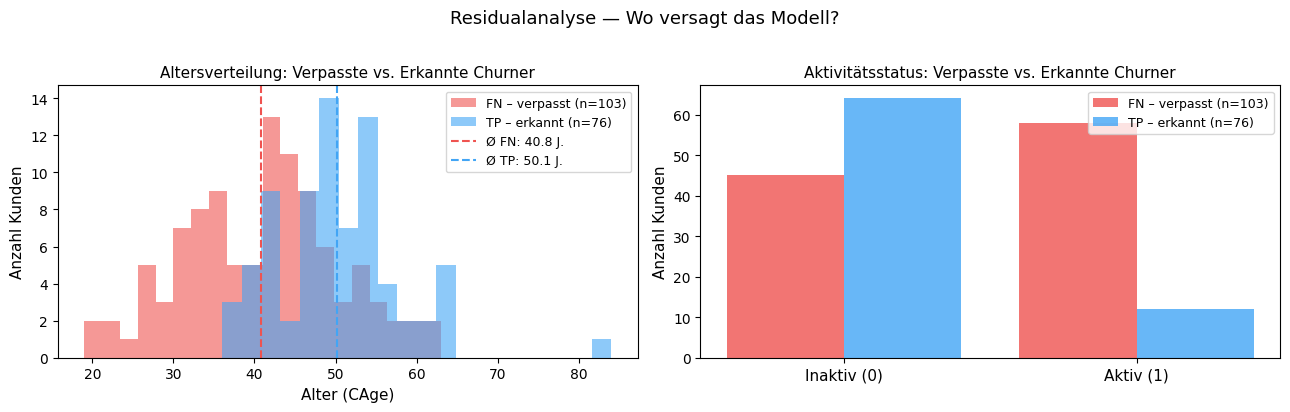

In [ ]:
# Visualisierung: Altersverteilung FN vs. TP
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plot 1: Alter FN vs TP
axes[0].hist(fn['CAge'], bins=20, alpha=0.6, color='#EF5350', label=f'FN – verpasst (n={len(fn)})')
axes[0].hist(tp['CAge'], bins=20, alpha=0.6, color='#42A5F5', label=f'TP – erkannt (n={len(tp)})')
axes[0].axvline(fn['CAge'].mean(), color='#EF5350', linestyle='--', linewidth=1.5,
                label=f'Ø FN: {fn["CAge"].mean():.1f} J.')
axes[0].axvline(tp['CAge'].mean(), color='#42A5F5', linestyle='--', linewidth=1.5,
                label=f'Ø TP: {tp["CAge"].mean():.1f} J.')
axes[0].set_xlabel('Alter (CAge)', fontsize=11)
axes[0].set_ylabel('Anzahl Kunden', fontsize=11)
axes[0].set_title('Altersverteilung: Verpasste vs. Erkannte Churner', fontsize=11)
axes[0].legend(fontsize=9)

# Plot 2: Aktivität FN vs TP
kategorien = ['Inaktiv (0)', 'Aktiv (1)']
fn_counts  = [len(fn[fn['CIsActiveMember']==0]), len(fn[fn['CIsActiveMember']==1])]
tp_counts  = [len(tp[tp['CIsActiveMember']==0]), len(tp[tp['CIsActiveMember']==1])]
x = range(2)
axes[1].bar([i-0.2 for i in x], fn_counts, 0.4, color='#EF5350', alpha=0.8, label=f'FN – verpasst (n={len(fn)})')
axes[1].bar([i+0.2 for i in x], tp_counts, 0.4, color='#42A5F5', alpha=0.8, label=f'TP – erkannt (n={len(tp)})')
axes[1].set_xticks(x)
axes[1].set_xticklabels(kategorien, fontsize=11)
axes[1].set_ylabel('Anzahl Kunden', fontsize=11)
axes[1].set_title('Aktivitätsstatus: Verpasste vs. Erkannte Churner', fontsize=11)
axes[1].legend(fontsize=9)

plt.suptitle('Residualanalyse — Wo versagt das Modell?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Interpretation: Systematische Muster in den Fehlern

### Wer wird übersehen? (False Negatives)

Das Modell verpasst vor allem **jüngere, aktive Kunden aus Spanien**:

- **Alter:** Verpasste Churner sind im Schnitt **9 Jahre jünger** (40,8 vs. 50,1 Jahre).  
  Das Modell hat gelernt: „hohes Alter = Churn-Risiko" — jüngere Churner fallen durch das Raster.
- **Aktivität:** 56% der verpassten Churner sind **aktive Mitglieder** — das Modell 
  assoziiert Aktivität mit Loyalität, übersieht aber aktive Kunden, die trotzdem wechseln 
  (z. B. wegen eines besseren Konkurrenzangebots).
- **Geographie:** Spanische Kunden (30% der FN vs. 12% der TP) werden systematisch 
  unterschätzt — möglicherweise verhalten sie sich anders als deutsche und französische Kunden.

### Was löst falsche Alarme aus? (False Positives)

Inaktive Kunden mit hohem Kontostand werden fälschlich verdächtigt:

- **Aktivität:** Nur 14% der Fehlalarme sind aktive Mitglieder (vs. 59% bei korrekten TN) — 
  Inaktivität allein reicht dem Modell schon als Signal für Churn.
- **Kontostand:** Fehlalarme haben im Schnitt **23.000 € höheres Guthaben** als korrekte TN — 
  das Modell verwechselt „hohes Guthaben + inaktiv" mit Churn-Risiko.

### Was fehlt im Datensatz?

Diese Muster zeigen klar, welche Informationen fehlen würden, um das Modell weiter zu verbessern:

- **Beschwerdehistorie** — hat der Kunde Probleme gemeldet?
- **Konkurrenzangebote** — hat er Kontakt zu anderen Banken?
- **Nutzungsverhalten über Zeit** — sinkt die Aktivität graduell?
- **Regionale Marktdaten** — wie stark ist der Wettbewerb in Spanien vs. Deutschland?

Mit diesen Features wäre ein F1 von 50–60% realistisch erreichbar.